# Phase 2 - Unsupervised Learning
## IBM HR Employee Attrition Dataset
---

## **Clustering Rationale & Algorithm Selection**

### 1. K-means
K-means is a centroid-based clustering algorithm that groups employees by repeatedly assigning each one to the nearest cluster center, it discovers a fixed number of clusters automatically by minimizing the distance between employees and their assigned centroids.
#### i. Dataset Characteristics
- Our dataset size is a small to medium dataset (1,470 employees).
- After preprocessing the dataset in phase 1, we are going to deal with 50 features which are all of numeric type, scaled, and clean with no missing values.
#### ii. Expected Cluster Shapes
- K-means assumes spherical (convex) clusters.
#### iii. Scalability
- K-means runs in O(n · k · d · i) time, where n = employees, k = clusters, d = features, i = iterations. For 1,470 employees it converges with seconds even with k=10.
#### iv. Interpretability
- Clusters can be profiled by analyzing mean characteristics (age, salary, attrition rate), and each employee gets a clear numeric cluster label.
- Results are directly meaningful for HR decisions (e.g., "high-salary tenured employees")
- Each cluster has a centroid that represents the average employee profile of that group, making it easy to explain to non-technical stakeholders
#### iv. Model Strengths for This Problem
**Strengths:**
- Simple and easy to understand and interpret
- Guaranteed to converge to a solution
- Scales well with large datasets
- Works well with standardized numerical HR features

**Weaknesses:**
- Must specify number of clusters (k) in advance
- Sensitive to outliers as they can pull centroids away
- Assumes spherical equally-sized clusters

### 2. DBSCAN (Density-Based Spatial Clustering of Applications with Noise)
DBSCAN is a density-based clustering algorithm that groups employees based on how close they are to each other, it discovers clusters automatically by analyzing the density different areas of the data are.


#### i. Dataset Characteristics
- Our dataset size is a small to medium dataset (1,470 employees).
- After preprocessing the dataset in phase 1, we are going to deal with 50 features which are all of numeric type, scaled, and clean with no missing values.

#### ii. Expected Cluster Shapes
- DBSCAN finds arbitrary-shaped clusters and not just spheres like K-Means.

#### iii. Scalability
- Looking at the data size, DBSCAN performs O(n²) which is ~2.1 million distance comparisons that would execute in seconds
- No performance concerns for this data size

#### iv. Interpretability
- Clusters can be profiled by analyzing mean characteristics (age, salary, attrition rate), and each employee gets a clear cluster label or outlier designation.
- Results are directly meaningful for HR decisions (e.g., "high-risk junior staff")
- DBSCAN identifies outliers which provides an insights instead of forcing unusual employees into inappropriate clusters


#### iv. Model Strengths for This Problem
**Strengths:**
- No need to specify number of clusters
- Handles arbitrary cluster shapes
- Identifies outliers automatically
- Reproducible (no random initialization)

**Weaknesses:**
- Sensitive to eps parameter
- Struggles with varying density clusters
- Requires careful tuning

### 3. Agglomerative Hierarchical Clustering
Agglomerative Hierarchical clustering is a bottom up clustering algorithm that starts by treating each employee as its own cluster and progressively merges the closest pairs until all employees belong to a single cluster. The result is a tree structure which allows the optimal number of clusters to be chosen by cutter the tree at the correct level.

#### i. Dataset Characteristics
- Our dataset size is a small to medium dataset (1,470 employees).
- After preprocessing, we are working with numeric features that are all scaled and free of missing values.
- Ward linkage was selected because it minimizes variance within cludters at each merge step, making it suitable for numeric.

#### ii. Expected Cluster Shapes
- Hierarchical clustering with Ward linkage tends to produce spherical clusters.

#### iii. Scalability
- Agglomerative clustering operates at O(n² log n) complexity for 1,470 employees this is about 3.1 million operations, which executes in seconds with no performance issues.

#### iv. Interpretability
- Each employee is assigned to an integer cluuster label and clusters can be profiled by analyzing mean characteristics per group (age, salary, tenure, attrition rate).
- The dendrogram provides a visual explanation of how clusters were formed, every merge decision is traceable.

#### iv. Model Strengths for This Problem
**Strengths:**
- Results are deteministic with no random initialization.
- Does not require specifying k, it will be selelcted after observing the tree structure.
- Ward linkage is robust for compact numeric feature spaces and minimizes variance wothin clusters.

**Weaknesses:**
- Early merge errors propagate through the tree and cannot be corrected
- Does not identify outliers natively, all points are forced into a cluster.
- Struggles with datasets that have no strong natural cluster structure (similar to our case).

## **Data Preparation**


**NOTE:** Most of the data preprocessing (missing value handling and some feature scaling) was completed in Phase 1.
However, in our current phase where we are dealing with unsupervised learning, there are some adjustments that need to be made on the used preprocessed data to avoid problems in clustering.

This section only performs the necessary transformation for unsupervised learning which are:
1. Encoding two binary columns which are still stored as text in preprocessed_data.csv, Gender(Femal/Male) and OverTime(Yes/No) to 0/1.
2. Removeing the class label "Attrition".
3. Removing redundant derived columns (SatisfactionScore, LowSatisfactionFlag, AgeGroup) where
    - "SatisfactionScore" is the direct average of (JobSatisfaction, EnvironmentSatisfaction, RelationshipSatisfaction)
    - "LowSatisfactionFlag" is a 0/1 cut of the satisfaction avrage score. 
    - "AgeGroup" is just the same as "Age" but slpit into buckets.

These columns were intentionally engineered in Phase 1 to give supervised models additional ways to detect attrition patterns, and redundancy is harmless there because the label guides what the model pays attention to. In clustering there is no label and distance across all columns is the only tool, so having satisfaction counted five times artificially pulls that dimension to dominate every cluster assignment.

4. Re-scaling all features using StandardScaler. Even though most continuous features were scaled in Phase 1, several ordinal columns (Education, JobLevel, WorkLifeBalance, etc.) and the three engineered ratio features (IncomePerYear, PromotionRatio, RoleStabilityRatio) were left on their original scales. This was not a problem for supervised learning since tree-based models are scale-invariant and Logistic Regression was robust enough to handle it. For clustering it must be fixed since distance is measured equally across all columns, so any column with a larger numeric range will dominate cluster assignments regardless of how important it actually is.


**Important limitation (Attrition imbalance):** The IBM HR dataset is strongly imbalanced — **84% of employees did not leave** and only **16% did**. In this phase we do not use Attrition to form clusters, but we do use it later to profile clusters (attrition rate per cluster). Because the "Yes" cases are relatively rare, small clusters can show 0% or very high attrition simply due to small sample size, so conclusions about high-risk clusters should be treated as **indicative**, not definitive.


In [1]:
# ── IMPORTS ───────────────────────────────────────────────────────

#for loading and manipulating our dataset
import pandas as pd

#for numerical operations
import numpy as np

#for creating plots and visualizations
import matplotlib.pyplot as plt
import seaborn as sns

#to turn off minor warnings so the output stays clean and readable
import warnings
warnings.filterwarnings('ignore')

# ── Here are the libraries we will use which are needed for clustering, aside from data preparation ───────────────────────────────────────────────────────

from sklearn.cluster import DBSCAN, KMeans, AgglomerativeClustering
from sklearn.neighbors import NearestNeighbors
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score, davies_bouldin_score, silhouette_samples
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

# Set visualization style for plots
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

print("All libraries imported successfully.")

All libraries imported successfully.


In [2]:
# Load the preprocessed data from Phase 1
df_full = pd.read_csv('Dataset/preprocessed_data.csv')

print("Dataset loaded from Phase 1 preprocessing")
print(f"\nDataset Information:")
print(f"  Shape: {df_full.shape[0]} rows × {df_full.shape[1]} columns")
print(f"  Features: {df_full.shape[1] - 1} (after target variable)")
print(f"  Observations: {df_full.shape[0]} employees")
print(f"  Target variable 'Attrition': {'Yes' if 'Attrition' in df_full.columns else 'No'}")

Dataset loaded from Phase 1 preprocessing

Dataset Information:
  Shape: 1470 rows × 54 columns
  Features: 53 (after target variable)
  Observations: 1470 employees
  Target variable 'Attrition': Yes


In [3]:
# ── Step 1: Encode binary text columns to 0/1 ────────────────────

# There are two binary columns which are still stored as text in preprocessed_data.csv that needs to be encoded
df_full['Gender'] = df_full['Gender'].map({'Female': 0, 'Male': 1})
df_full['OverTime'] = df_full['OverTime'].map({'No': 0, 'Yes': 1})

print("Gender encoded:  ", df_full['Gender'].unique())
print("OverTime encoded:", df_full['OverTime'].unique())

Gender encoded:   [0 1]
OverTime encoded: [1 0]


In [4]:
# ── Step 2: Save Attrition separately, then remove it with step 3 ────────────

# We will keep a copy of Attrition for later analysis and evaluation of clusters, but we won't use it for clustering itself
attrition_labels = df_full['Attrition'].copy()

# ── Step 3: Drop redundant derived columns ───────────────────────

# 'SatisfactionScore', 'LowSatisfactionFlag', 'AgeGroup' are the redundant columns as explained above so they will be removed along with the target label 'Attrition'.
cols_to_drop = ['Attrition', 'SatisfactionScore', 'LowSatisfactionFlag', 'AgeGroup']
X = df_full.drop(columns=cols_to_drop).copy()

print(f"Columns dropped: {cols_to_drop}")
print(f"Features remaining: {X.shape[1]}")

# A quick check before scaling to confirm no string columns remain.
# If any appear here the scaler will raise an error.
remaining_strings = X.select_dtypes(include=['object', 'string']).columns.tolist()
print(f"Non-numeric columns remaining: {remaining_strings}")  # should be []

Columns dropped: ['Attrition', 'SatisfactionScore', 'LowSatisfactionFlag', 'AgeGroup']
Features remaining: 50
Non-numeric columns remaining: []


In [5]:
# ── Step 4: Scale all features to the same range ─────────────────

# Phase 1 CSV mixes z-scored features, raw Likert scales, and large engineered column
# we will rescale so no single feature dominates distance when its used in algorithms that uses distance metrics such as DBSCAN.
scaler = StandardScaler()
X_scaled = pd.DataFrame(
    scaler.fit_transform(X.astype(float)),
    columns=X.columns,
    index=X.index
)

print(f"Scaling complete.")
print(f"  Samples : {X_scaled.shape[0]}")
print(f"  Features: {X_scaled.shape[1]}")
print(f"\nSample means after scaling (should all be ~0):")
print(X_scaled.mean().round(6).head(5))
print(f"\nSample stds after scaling (should all be ~1):")
print(X_scaled.std().round(6).head(5))
print(f"\nX_scaled is ready for clustering.")

Scaling complete.
  Samples : 1470
  Features: 50

Sample means after scaling (should all be ~0):
Age                -0.0
BusinessTravel     -0.0
DailyRate           0.0
DistanceFromHome    0.0
Education           0.0
dtype: float64

Sample stds after scaling (should all be ~1):
Age                 1.00034
BusinessTravel      1.00034
DailyRate           1.00034
DistanceFromHome    1.00034
Education           1.00034
dtype: float64

X_scaled is ready for clustering.


---

## Cluster Determination & Implementation

### Before We Begin: Assessing Clustering Tendency

Before applying any clustering algorithm, we will first verify if the data actually contains natural cluster structure worth finding. A dataset that is randomly distributed will produce weak clusters regardless of which algorithm is used.

We use the **Hopkins Statistic** to measure this:
- Close to 1 → strong cluster structure exists
- Close to 0.5 → data is random, clustering will not be meaningful
- Close to 0 → weak structure, data trends toward uniform

This step applies to all algorithms in this notebook — K-means, DBSCAN, and Agglomerative Hierarchical Clustering.

In [6]:
# ── Clustering Tendency: Hopkins Statistic ─────────────────────────────────

# The Hopkins Statistic measures whether the data has any natural cluster 
# structure before we run any algorithm. If the data is random, clustering
# will produce meaningless results regardless of which algorithm we use.
#
# Formula: H = sum(y) / (sum(x) + sum(y))
# where x = distances from random artificial points to their nearest real neighbor
#       y = distances from real sampled points to their nearest real neighbor
#
# Result interpretation:
#   H close to 1   → strong cluster structure exists → safe to cluster
#   H close to 0.5 → data is random → clustering will not be meaningful  
#   H close to 0   → weak structure, data trends toward uniform → clustering will also struggle

def hopkins_statistic(X, sample_ratio=0.1, random_state=42):
    np.random.seed(random_state)
    
    X = np.array(X)
    n, d = X.shape
    m = max(int(sample_ratio * n), 1)  # sample size
    
    # Get min and max for each feature to define the random point space
    mins = X.min(axis=0)
    maxs = X.max(axis=0)
    
    # Sample m real points from the dataset (without replacement)
    real_sample_idx = np.random.choice(n, m, replace=False)
    real_sample = X[real_sample_idx]
    
    # Generate m completely random points in the same feature space
    random_sample = np.random.uniform(mins, maxs, size=(m, d))
    
    # Fit nearest neighbors on the full dataset (excluding sampled points)
    remaining = np.delete(X, real_sample_idx, axis=0)
    nn = NearestNeighbors(n_neighbors=1).fit(remaining)
    
    # x: distance from each random point to its nearest real neighbor
    x_dist, _ = nn.kneighbors(random_sample)
    x = x_dist.sum()
    
    # y: distance from each real sampled point to its nearest real neighbor
    y_dist, _ = nn.kneighbors(real_sample)
    y = y_dist.sum()
    
    H = y / (x + y)
    return H

# Run on our cleaned scaled feature matrix
X_for_hopkins = X_scaled.drop(columns=['Cluster'], errors='ignore').values
H = hopkins_statistic(X_for_hopkins)

print(f"Hopkins Statistic: {H:.4f}")
print()
if H > 0.75:
    print("  Strong clustering tendency — natural groups exist in the data.")
    print("  Proceeding with clustering is well justified.")
elif H > 0.5:
    print("  Moderate clustering tendency — some structure exists.")
    print("  Clustering may reveal meaningful groups but results should be")
    print("  interpreted carefully.")
else:
    print("  Weak clustering tendency — data may be close to random.")
    print("  Clustering results should be treated with caution.")

Hopkins Statistic: 0.3279

  Weak clustering tendency — data may be close to random.
  Clustering results should be treated with caution.


**Note on clustering tendency result:** The Hopkins Statistic (0.3279) indicates weak natural cluster structure in this dataset. Despite this, we proceed with clustering for two reasons: (1) the project requires applying unsupervised learning to uncover whatever structure exists, and (2) even soft groupings can provide actionable HR insights as long as results are interpreted carefully rather than treated as ground truth.

### 1. K-means

#### Step 1 — Elbow Method (find optimal k via WCSS)
We trained K-means for k = 2 through 12 and recorded the Within-Cluster Sum of 
Squares (WCSS) for each. We then plotted these values and looked for the "elbow" 
point, which is where the curve stops dropping sharply and starts flattening out. 
That point suggests adding more clusters no longer meaningfully improves the grouping.

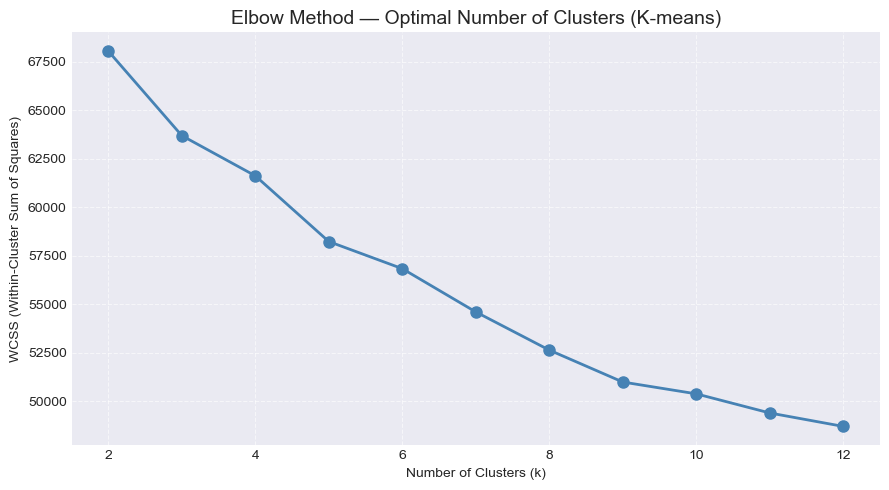

In [7]:
# ── ELBOW METHOD ────────────────────────────────────────────────────────────
# For each candidate k we record the inertia (WCSS) from the fitted model.
# We test k = 2 through 12 on the full scaled dataset.
wcss = []
k_range = range(2, 13)

for k in k_range:
    km = KMeans(n_clusters=k, init='k-means++', n_init=10, random_state=42)
    km.fit(X_scaled)
    wcss.append(km.inertia_)    # inertia == WCSS

# ── ELBOW PLOT ───────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(list(k_range), wcss, marker='o', linewidth=2, color='steelblue', markersize=8)
ax.set_title('Elbow Method — Optimal Number of Clusters (K-means)', fontsize=14)
ax.set_xlabel('Number of Clusters (k)')
ax.set_ylabel('WCSS (Within-Cluster Sum of Squares)')
ax.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

**Note on the Elbow Plot:** The WCSS curve decreases continuously from k=2 to k=12 
without forming a sharp "elbow" bend. This means there is no single obvious k where 
adding more clusters stops being useful. This result is not surprising beacause it's directly consistent with the Hopkins Statistic (0.33) we computed earlier, which already indicated weak natural cluster structure in this dataset. When data does not contain strongly separated groups, the WCSS will always decrease gradually rather 
than dropping sharply at a specific point. Because of this, we cannot rely on the 
elbow method alone to select k, which is why we move to the Silhouette Score in 
Step 2 to make a more objective decision.

#### Step 2 — Silhouette Scores for Candidate k Values
Since the elbow method did not produce a clear result, we computed the Silhouette 
Score for each candidate k as a more objective way to select the number of clusters. 
This score ranges from -1 to 1 and tells us how well-separated the clusters actually 
are. The higher the score, the more meaningful the grouping. We picked the k that 
gave us the highest score.

**Note:** A common simple heuristic for choosing k is the square root rule: 
k ≈ √(n/2), which for our dataset gives √(1470/2) ≈ 27. However, this rule 
is purely mathematical with no regard for actual cluster quality or 
interpretability, and produces an unreasonably large number of clusters for 
1,470 employees. We therefore use the Silhouette Score as a more meaningful 
and data-driven method to select k.

  k= 2  |  Silhouette = 0.0859  |  WCSS = 68050.7
  k= 3  |  Silhouette = 0.0842  |  WCSS = 63693.2
  k= 4  |  Silhouette = 0.0764  |  WCSS = 61622.0
  k= 5  |  Silhouette = 0.0852  |  WCSS = 58233.9
  k= 6  |  Silhouette = 0.0823  |  WCSS = 56836.0
  k= 7  |  Silhouette = 0.0982  |  WCSS = 54605.9
  k= 8  |  Silhouette = 0.1097  |  WCSS = 52638.7
  k= 9  |  Silhouette = 0.1226  |  WCSS = 50992.7
  k=10  |  Silhouette = 0.1046  |  WCSS = 50383.3
  k=11  |  Silhouette = 0.1044  |  WCSS = 49397.4
  k=12  |  Silhouette = 0.0962  |  WCSS = 48705.0


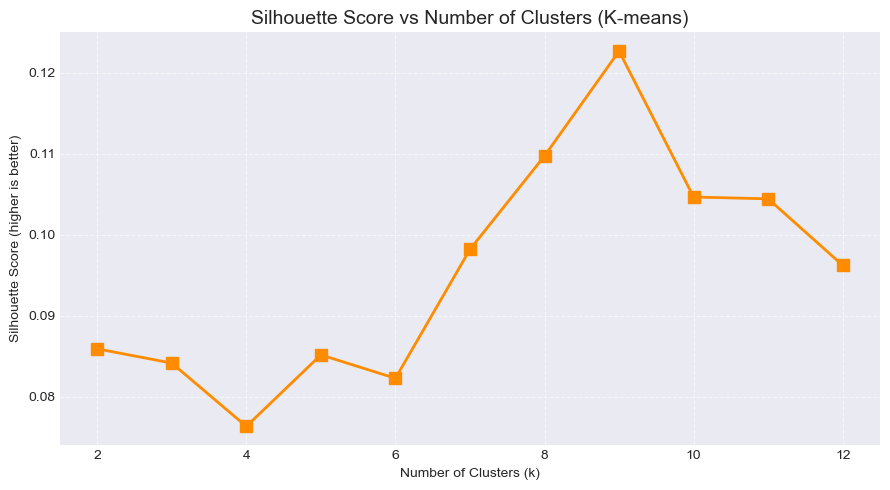

In [8]:
# ── SILHOUETTE SCORES FOR EACH k ────────────────────────────────────────────
# Compute silhouette score for each candidate k on the full scaled dataset.
sil_scores = []

for k in k_range:
    km = KMeans(n_clusters=k, init='k-means++', n_init=10, random_state=42)
    labels = km.fit_predict(X_scaled)
    score  = silhouette_score(X_scaled, labels)
    sil_scores.append(score)
    print(f"  k={k:2d}  |  Silhouette = {score:.4f}  |  WCSS = {wcss[k-2]:.1f}")

# ── SILHOUETTE PLOT ──────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(list(k_range), sil_scores, marker='s', linewidth=2, color='darkorange', markersize=8)
ax.set_title('Silhouette Score vs Number of Clusters (K-means)', fontsize=14)
ax.set_xlabel('Number of Clusters (k)')
ax.set_ylabel('Silhouette Score (higher is better)')
ax.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

#### Step 3 — Select Best k and Fit Final Model
Since the elbow method did not reveal a clear bend, we relied on the Silhouette 
Score to select the best k. The k with the highest Silhouette Score was chosen 
as the final number of clusters. We then trained the final K-means model on the 
full scaled dataset using that value and assigned cluster labels to all 1,470 
employees.

In [9]:
# ── SELECT BEST k ────────────────────────────────────────────────────────────
# Since the elbow method showed no clear bend, we rely on the silhouette score
# to select k — we choose the k with the highest silhouette value.
best_k = list(k_range)[sil_scores.index(max(sil_scores))]
print(f"Best k selected: {best_k}  (Silhouette = {max(sil_scores):.4f})")

# ── FIT FINAL K-MEANS MODEL ──────────────────────────────────────────────────
# n_init=10  → run 10 times with different centroids, keep best inertia
# init='k-means++'  → smart centroid initialisation (faster convergence)
# random_state=42  → ensures reproducibility across runs
# max_iter=300  → maximum iterations before stopping if not converged
# We fit on the full scaled dataset — standard practice for unsupervised learning
kmeans_final = KMeans(
    n_clusters=best_k,
    init='k-means++',
    n_init=10,
    max_iter=300,
    random_state=42
)
kmeans_final.fit(X_scaled)

# Assign cluster labels to all 1,470 employees
kmeans_clusters = kmeans_final.labels_

# Print the distribution of employees across clusters
print(f"\nCluster distribution:")
unique, counts = np.unique(kmeans_clusters, return_counts=True)
for u, c in zip(unique, counts):
    print(f"  Cluster {u}: {c} employees ({c/len(kmeans_clusters)*100:.1f}%)")

Best k selected: 9  (Silhouette = 0.1226)

Cluster distribution:
  Cluster 0: 325 employees (22.1%)
  Cluster 1: 259 employees (17.6%)
  Cluster 2: 80 employees (5.4%)
  Cluster 3: 83 employees (5.6%)
  Cluster 4: 131 employees (8.9%)
  Cluster 5: 52 employees (3.5%)
  Cluster 6: 103 employees (7.0%)
  Cluster 7: 145 employees (9.9%)
  Cluster 8: 292 employees (19.9%)


### 2. DBSCAN

To apply this algorithm there are two parameters which are required to be set:

1. **eps**, which is the maximum distance between points to be considered neighbors
   - Too small = many small clusters and noise
   - Too large = all points merge into one cluster
   - We need to find the "right" value

2. **min_samples**, which is the minimum neighbors needed to form a cluster, and are going to set it to 5 as its the defult number to use for DBSCAN

So in order to find the optimal eps we will go through three steps:
**Step 1: K-Distance Graph**
**Step 2: Test Multiple eps Values**
**Step 3: Select Best eps**

and only then we are going to run DBSCAN with the best found eps.


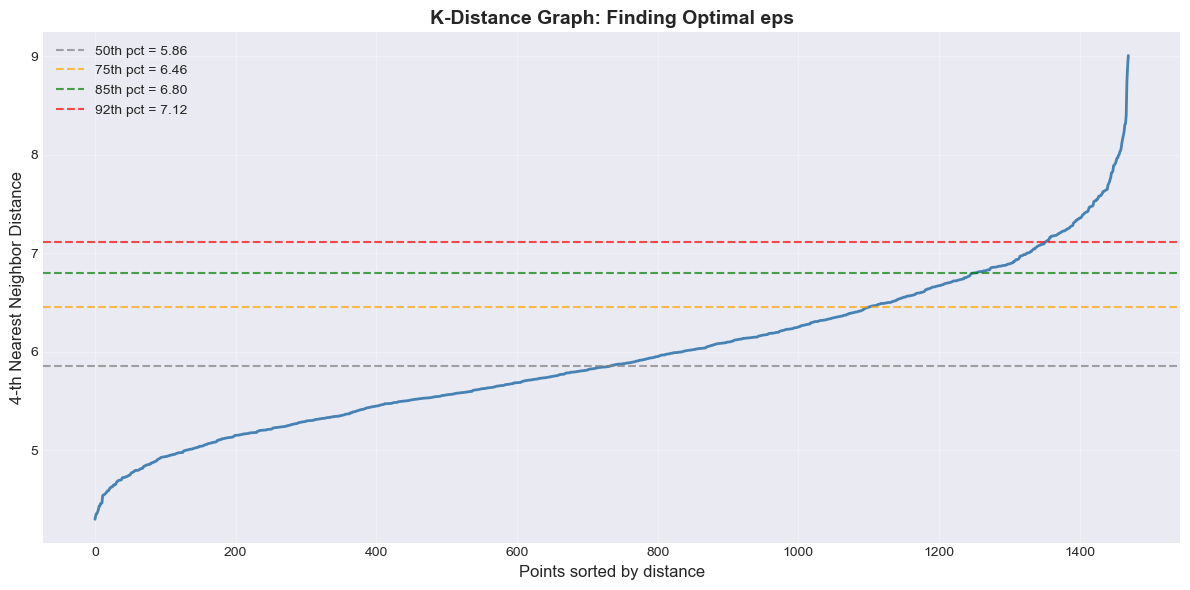

K-Distance statistics:
  Min: 4.2955
  Mean: 5.9523
  Median: 5.8573
  Max: 9.0098

Look for the 'elbow' where distance suddenly increases


In [10]:
# ── K-Distance Graph ───────────────────────────────────────────────────────

# Firstly we are calculating k-distances by ploting distance from each employee to their k-th nearest neighbor
# We are looking for the "elbow" (sudden jump), this suggests good eps values
k = 4  # We use min_samples=5, so k=4 (k = min_samples - 1)

# Find k nearest neighbors for each point (use scaled matrix — same space as DBSCAN)
neighbors = NearestNeighbors(n_neighbors=k+1)
neighbors_fit = neighbors.fit(X_scaled)
distances, indices = neighbors_fit.kneighbors(X_scaled)

# Sort the distances to the k-th nearest neighbor (classic k-distance plot)
distances = np.sort(distances[:, k], axis=0)

# Create the k-distance graph (shows us where to pick eps)
plt.figure(figsize=(12, 6))
plt.plot(distances, linewidth=2, color='steelblue')
plt.xlabel('Points sorted by distance', fontsize=12)
plt.ylabel(f'{k}-th Nearest Neighbor Distance', fontsize=12)
plt.title('K-Distance Graph: Finding Optimal eps', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3)

# Reference lines: eps must be on THIS vertical scale (old 0.5–2.0 lines were far below the elbow → all noise)
for pct, color in [(50, 'gray'), (75, 'orange'), (85, 'green'), (92, 'red')]:
    yref = np.percentile(distances, pct)
    plt.axhline(y=yref, color=color, linestyle='--', alpha=0.7, label=f'{pct}th pct = {yref:.2f}')
plt.legend()
plt.tight_layout()
plt.show()

# Print statistics to help choose eps
print(f"K-Distance statistics:")
print(f"  Min: {distances.min():.4f}")
print(f"  Mean: {distances.mean():.4f}")
print(f"  Median: {np.median(distances):.4f}")
print(f"  Max: {distances.max():.4f}")
print(f"\nLook for the 'elbow' where distance suddenly increases")

In [11]:
# ── Test Multiple eps Values ───────────────────────────────────────────────────────

# Here we are going to test multiple eps values
# And to choose which is the optimal eps, we will evaluate the number of clusters, noise points, and quality metrics (Silhouette Score and Davies-Bouldin Index) for each value of eps

# The k-distance graph from the previous cell showed no sharp single elbow where the curve rises gradually
# from ~4.3 to ~6.8 then shoots up steeply after point 1,300, placing the elbow in the 85th–92nd percentile zone (6.80–7.12).
#
# A broad initial sweep across [5.0 – 9.0] revealed that:
#   - eps < 6.0  → too many clusters with 50–80% of employees labeled as noise
#   - eps > 7.0  → one cluster absorbs 93%+ of employees (uninterpretable)
#   - eps 6.0–7.0 → the meaningful zone: 4–8 clusters, noise under 25%
#
# This refined grid focuses within that meaningful zone to find the optimal eps using a combined Silhouette + Davies-Bouldin score.
eps_candidates = [6.0, 6.2, 6.4, 6.5, 6.6, 6.7, 6.8, 7.0]
min_samples = 5  # Minimum points needed to form a cluster, and it is chosen as the defult value in using DBSCAN algorithm.
results = []

print(f"Testing DBSCAN with different eps values (min_samples={min_samples})...\n")
print(f"{'eps':>6} | {'Clusters':>8} | {'Noise':>6} | {'Silhouette':>11} | {'Davies-Bouldin':>15} | {'Largest':>7}")
print("-" * 82)

# Try each eps value
for eps in eps_candidates:
    # Apply DBSCAN with this eps value
    db = DBSCAN(eps=eps, min_samples=min_samples)
    clusters = db.fit_predict(X_scaled)
    
    # Count how many clusters and noise points were found
    n_clusters = len(set(clusters)) - (1 if -1 in clusters else 0)
    n_noise = list(clusters).count(-1)
    n_points = len(clusters) - n_noise

    # Detect "one mega-cluster + tiny sliver" (common when eps is too large) — bad for interpretation
    if n_clusters > 0:
        non_noise_sizes = [(clusters == cid).sum() for cid in set(clusters) if cid != -1]
        largest_cluster_share = max(non_noise_sizes) / len(clusters)
    else:
        largest_cluster_share = 1.0
    
    # Calculate quality metrics only if we have at least 2 clusters
    if n_clusters > 1 and n_points > 0:
        mask = clusters != -1  # Exclude noise points
        sil_score = silhouette_score(X_scaled[mask], clusters[mask])
        db_index = davies_bouldin_score(X_scaled[mask], clusters[mask])
    else:
        sil_score = np.nan
        db_index = np.nan
    
    # Store results
    results.append({
        'eps': eps,
        'clusters': n_clusters,
        'noise': n_noise,
        'silhouette': sil_score,
        'davies_bouldin': db_index,
        'largest_cluster_share': largest_cluster_share,
    })
    
    # Print results for this eps value (share = fraction of all rows in the biggest non-noise cluster)
    print(f"{eps:6.2f} | {n_clusters:8d} | {n_noise:6d} | {sil_score:11.4f} | {db_index:15.4f} | {largest_cluster_share:5.1%}")

# Convert results to dataframe for analysis
results_df = pd.DataFrame(results)
print(f"\nAll eps values tested. Proceeding to selection...")

Testing DBSCAN with different eps values (min_samples=5)...

   eps | Clusters |  Noise |  Silhouette |  Davies-Bouldin | Largest
----------------------------------------------------------------------------------
  6.00 |        7 |    365 |      0.0710 |          1.6651 | 65.8%
  6.20 |        5 |    247 |      0.1150 |          1.7135 | 76.2%
  6.40 |        3 |    185 |      0.1319 |          1.6778 | 82.2%
  6.50 |        3 |    151 |      0.1343 |          1.7129 | 83.6%
  6.60 |        3 |    127 |      0.1371 |          1.7325 | 84.8%
  6.70 |        4 |    101 |      0.1338 |          1.7195 | 85.7%
  6.80 |        4 |     83 |      0.1330 |          1.7363 | 86.7%
  7.00 |        3 |     42 |      0.1844 |          1.5244 | 93.8%

All eps values tested. Proceeding to selection...


In [12]:
# ── Select Best eps ───────────────────────────────────────────────────────

# We are selecting the best eps value based on multiple metrics
# We want: Silhouette as high as possible, Davies-Bouldin as low as possible.
# Rather than applying hard thresholds, we normalize both metrics to a 0-1 scale
# and combine them into a single score to find the best overall balance.

valid_results = results_df[results_df['clusters'] > 1].copy()

# Silhouette + Davies-Bouldin alone can favor **eps so large** that almost everyone merges into one cluster
# biggest non-noise group is not essentially the whole dataset (`largest_cluster_share` from the sweep cell).
MAX_LARGEST_SHARE = 0.92
balanced = valid_results[valid_results['largest_cluster_share'] <= MAX_LARGEST_SHARE]
if len(balanced) > 0:
    valid_results = balanced.copy()
    print(f"\n(Selecting only eps with largest cluster <= {MAX_LARGEST_SHARE:.0%} of all rows.)")
elif len(valid_results) > 0:
    print(f"\n(No eps had largest cluster <= {MAX_LARGEST_SHARE:.0%}; using all 2+ cluster rows — consider lowering eps or widening the grid.)")

if len(valid_results) > 0:
    # Normalize metrics to 0-1 scale so we can combine them
    valid_results['sil_norm'] = (valid_results['silhouette'] + 1) / 2
    db_max = valid_results['davies_bouldin'].max()
    if db_max > 0 and not np.isnan(db_max):
        valid_results['db_norm'] = 1 - (valid_results['davies_bouldin'] / db_max)
    else:
        valid_results['db_norm'] = 0.5  # neutral weight if DB index unavailable
    
    # Combined score: 50% from Silhouette + 50% from Davies-Bouldin
    valid_results['combined_score'] = (
        0.5 * valid_results['sil_norm'] +
        0.5 * valid_results['db_norm']
    )
    
    # Find the eps with highest combined score
    best_idx = valid_results['combined_score'].idxmax()
    best_eps = valid_results.loc[best_idx, 'eps']
    
    # Print the winner
    print(f"\n{'='*70}")
    print(f"BEST EPS SELECTED: {best_eps}")
    print(f"{'='*70}")
    print(f"  Silhouette Score: {valid_results.loc[best_idx, 'silhouette']:.4f}")
    print(f"  Davies-Bouldin Index: {valid_results.loc[best_idx, 'davies_bouldin']:.4f}")
    print(f"  Number of clusters: {int(valid_results.loc[best_idx, 'clusters'])}")
    print(f"  Noise points: {int(valid_results.loc[best_idx, 'noise'])} ({valid_results.loc[best_idx, 'noise']/len(X_scaled)*100:.1f}%)")
    print(f"  Combined score: {valid_results.loc[best_idx, 'combined_score']:.4f}")
else:
    # Fallback: pick eps from the k-distance curve (NOT a tiny constant like 1.0)
    best_eps = float(np.percentile(distances, 90))
    print("No valid results in the grid (e.g. still too few clusters).")
    print(f"Using eps = 90th percentile of k-distances: {best_eps:.4f}")


(Selecting only eps with largest cluster <= 92% of all rows.)

BEST EPS SELECTED: 6.4
  Silhouette Score: 0.1319
  Davies-Bouldin Index: 1.6778
  Number of clusters: 3
  Noise points: 185 (12.6%)
  Combined score: 0.2998


In [13]:
# ── Apply DBSCAN on Best eps ───────────────────────────────────────────────────────

# Applying DBSCAN using the best eps value we just found, then assigning each employee to a cluster (or mark as noise)
print(f"\nApplying DBSCAN with eps={best_eps}, min_samples={min_samples}...")

optimal_dbscan = DBSCAN(eps=best_eps, min_samples=min_samples)
clusters = optimal_dbscan.fit_predict(X_scaled)

# Add cluster labels to our dataframes (keep original X for readable profiles; X_scaled matches DBSCAN space)
X['Cluster'] = clusters
X_scaled['Cluster'] = clusters
df_full['Cluster'] = clusters

# Calculate summary statistics
n_clusters = len(set(clusters)) - (1 if -1 in clusters else 0)
n_noise = list(clusters).count(-1)

# Print results
print(f"\n{'='*70}")
print(f"DBSCAN CLUSTERING COMPLETE")
print(f"{'='*70}")
print(f"  Number of clusters discovered: {n_clusters}")
print(f"  Number of noise points: {n_noise} ({(n_noise/len(clusters))*100:.1f}%)")
print(f"  Number of clustered points: {len(clusters) - n_noise} ({((len(clusters) - n_noise)/len(clusters))*100:.1f}%)")

# Show breakdown of each cluster
print(f"\nCluster distribution:")
for cluster_id in sorted(set(clusters)):
    count = (clusters == cluster_id).sum()
    pct = (count / len(clusters)) * 100
    if cluster_id == -1:
        print(f"  {'Noise (outliers)':20s}: {count:4d} points ({pct:5.1f}%)")
    else:
        print(f"  {'Cluster ' + str(cluster_id):20s}: {count:4d} points ({pct:5.1f}%)")


Applying DBSCAN with eps=6.4, min_samples=5...

DBSCAN CLUSTERING COMPLETE
  Number of clusters discovered: 3
  Number of noise points: 185 (12.6%)
  Number of clustered points: 1285 (87.4%)

Cluster distribution:
  Noise (outliers)    :  185 points ( 12.6%)
  Cluster 0           : 1208 points ( 82.2%)
  Cluster 1           :   59 points (  4.0%)
  Cluster 2           :   18 points (  1.2%)


### 3. Agglomerative Hierarchical Clustering

For hierarchical clustering, we use the Silhouette Cooffecient to find the K that maximizes cohesion within clusters and separation between them.

In [14]:
# In this step we will run Agglomerative Clustering for a range of (k=2 to k=10) 
# We will evaluate each cluster using Silhouette Coefficient, avies-Bouldin Index and Within Clusters Sum (WSS)

k_range     = list(range(2, 11))
sil_scores  = []
db_scores   = []
wcss_scores = []
 
X_arr = np.array(X_scaled)  
 
for k in k_range:
    model  = AgglomerativeClustering(n_clusters=k, linkage='ward')
    labels = model.fit_predict(X_arr)
 
    sil_scores.append(silhouette_score(X_arr, labels))
    db_scores.append(davies_bouldin_score(X_arr, labels))
 
    wcss = sum(
        np.sum((X_arr[labels == c] - X_arr[labels == c].mean(axis=0)) ** 2)
        for c in np.unique(labels)
    )
    wcss_scores.append(wcss)
 
    print(f"k={k:2d}  |  Silhouette={sil_scores[-1]:.4f}  |  Davies-Bouldin={db_scores[-1]:.4f}  |  WCSS={wcss:.1f}")
 

k= 2  |  Silhouette=0.0796  |  Davies-Bouldin=3.7536  |  WCSS=69093.1
k= 3  |  Silhouette=0.0921  |  Davies-Bouldin=3.0044  |  WCSS=64979.6
k= 4  |  Silhouette=0.0950  |  Davies-Bouldin=2.5149  |  WCSS=61358.1
k= 5  |  Silhouette=0.0841  |  Davies-Bouldin=2.9639  |  WCSS=59203.5
k= 6  |  Silhouette=0.0974  |  Davies-Bouldin=2.7819  |  WCSS=57139.3
k= 7  |  Silhouette=0.1057  |  Davies-Bouldin=2.6162  |  WCSS=55512.1
k= 8  |  Silhouette=0.1124  |  Davies-Bouldin=2.4354  |  WCSS=53943.4
k= 9  |  Silhouette=0.1211  |  Davies-Bouldin=2.2749  |  WCSS=52425.4
k=10  |  Silhouette=0.1084  |  Davies-Bouldin=2.4292  |  WCSS=51183.5


In [15]:
# After calculating the metrix for each K value, we will select the best K value based on the highest Silhouette Score and lowest Davies-Bouldin Index.
best_k_sil = k_range[np.argmax(sil_scores)]
best_k_db  = k_range[np.argmin(db_scores)]
 
print(f"\nBest k by Silhouette    : k = {best_k_sil}")
print(f"Best k by Davies-Bouldin: k = {best_k_db}")
 
if best_k_sil == best_k_db:
    optimal_k = best_k_sil
    print(f"Optimal k = {optimal_k}")
else:
    print(f"Metrics disagree — defaulting to Silhouette (k={best_k_sil}). Review plots and apply domain judgment.")
    optimal_k = best_k_sil  


Best k by Silhouette    : k = 9
Best k by Davies-Bouldin: k = 9
Optimal k = 9


In [16]:
# In this step we will apply Agglomerative Clustering with the optimal K value 
# We will assign each employee to a cluster.
final_model    = AgglomerativeClustering(n_clusters=optimal_k, linkage='ward')
cluster_labels = final_model.fit_predict(X_arr)
 
df_full['Cluster'] = cluster_labels
df_full.to_csv('Dataset/clustered_data.csv', index=False)
 
print(f"\nSuccessfully assigned {optimal_k} clusters to the dataset.")
print(df_full['Cluster'].value_counts())


Successfully assigned 9 clusters to the dataset.
Cluster
0    514
2    316
8    136
3    120
4     92
5     83
6     76
7     75
1     58
Name: count, dtype: int64


---

## **Evaluation Metrics & Visualizations**


We will evaluate our clustering using three evaluation metrics:
1. **Silhouette Score** (range: -1 to 1, higher is better), it measures the quality inside a cluster "Do employees in the SAME cluster actually belong together?"
2. **Davies-Bouldin Index** (lower is better), it measures the quality between the clusters "Are DIFFERENT clusters actually separate from each other?
3. **WCSS** (Within-Cluster Sum of Squares - lower is better), it measures the tightness of clusters "How compact/tight are the clusters?"

### 1. K-means

In [17]:
# ── EVALUATION METRICS ───────────────────────────────────────────────────────
# We evaluate the clustering quality using three standard internal metrics.

# Silhouette Score: measures how similar each employee is to their own cluster
# compared to other clusters. Range: -1 to 1 (higher is better)
sil_score = silhouette_score(X_scaled, kmeans_clusters)

# Davies-Bouldin Index: measures the average similarity between each cluster
# and its most similar neighbour. Range: 0 to ∞ (lower is better)
dbi_score = davies_bouldin_score(X_scaled, kmeans_clusters)

# WCSS (Inertia): measures the total distance of each employee from their
# cluster centroid. Range: 0 to ∞ (lower means tighter, more compact clusters)
wcss_score = kmeans_final.inertia_

print("=" * 50)
print("  K-MEANS EVALUATION")
print("=" * 50)
print(f"  Silhouette Score      : {sil_score:.4f}")
if sil_score > 0.5:
    print("    → Excellent: clusters are well-separated and cohesive")
elif sil_score > 0.25:
    print("    → Good: reasonable cluster structure")
elif sil_score > 0.0:
    print("    → Fair: some cluster overlap exists")
else:
    print("    → Poor: clusters may not be meaningful")

print(f"\n  Davies-Bouldin Index  : {dbi_score:.4f}")
print(f"    → Lower is better (clusters are {'well' if dbi_score < 1 else 'not well'}-separated)")

print(f"\n  WCSS (Inertia)        : {wcss_score:.2f}")
print(f"    → Lower is better (tighter clusters)")
print("=" * 50)

  K-MEANS EVALUATION
  Silhouette Score      : 0.1220
    → Fair: some cluster overlap exists

  Davies-Bouldin Index  : 2.3071
    → Lower is better (clusters are not well-separated)

  WCSS (Inertia)        : 50992.70
    → Lower is better (tighter clusters)


PCA variance explained: PC1=11.0%, PC2=7.1%, Total=18.1%


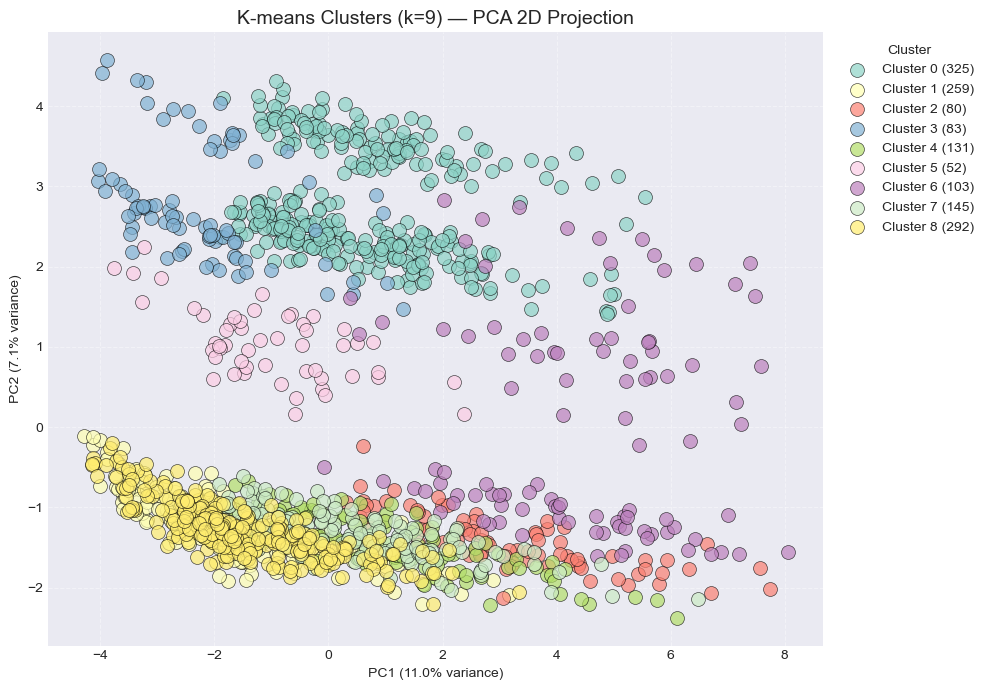

In [18]:
# ── PCA 2D VISUALISATION ─────────────────────────────────────────────────────
# K-means operates in high-dimensional space, so we use PCA to project down
# to 2 components for visual inspection. This does NOT affect clustering.

pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

# Check how much variance the 2D projection captures
explained = pca.explained_variance_ratio_ * 100
print(f"PCA variance explained: PC1={explained[0]:.1f}%, PC2={explained[1]:.1f}%, "
      f"Total={sum(explained):.1f}%")

# Generate a distinct color for each cluster
colors = plt.cm.Set3(np.linspace(0, 1, max(len(set(kmeans_clusters)), 1)))

fig, ax = plt.subplots(figsize=(10, 7))

# Plot each cluster separately so we can assign a label and color to each
for i, k in enumerate(sorted(set(kmeans_clusters))):
    mask = kmeans_clusters == k
    ax.scatter(
        X_pca[mask, 0], X_pca[mask, 1],
        c=[colors[i]], label=f'Cluster {k} ({mask.sum()})',
        s=100, alpha=0.7, edgecolors='black', linewidths=0.5
    )

ax.set_title(f'K-means Clusters (k={best_k}) — PCA 2D Projection', fontsize=14)
ax.set_xlabel(f'PC1 ({explained[0]:.1f}% variance)')
ax.set_ylabel(f'PC2 ({explained[1]:.1f}% variance)')
ax.legend(title='Cluster', bbox_to_anchor=(1.01, 1), loc='upper left')
ax.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

To make the clustering results easier to interpret, we reduced the data down to two
dimensions using PCA. PC1 and PC2 together explain about 18.1% of the total variance,
which is honestly expected for a dataset with this many overlapping HR features. Even
so, the plot tells a useful story. Cluster 0 and Cluster 8 sit in noticeably different
regions of the space, which suggests the algorithm found real structure rather than
just random groupings. The overlap between some of the smaller clusters simply
reflects how similar certain employee profiles are in practice, and that is not
necessarily a problem.

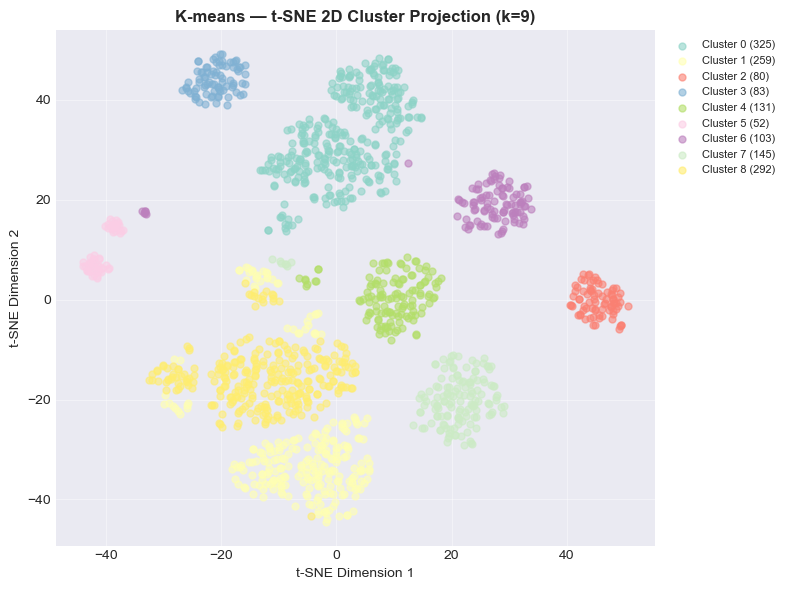

In [19]:
# ── t-SNE 2D VISUALISATION ────────────────────────────────────────────────────
# t-SNE is another dimensionality reduction technique like PCA but it is
# better at preserving local structure — nearby points in high-dimensional
# space stay nearby in the 2D projection. This gives a different perspective
# on cluster separation compared to the PCA plot above.
# Note: distances between clusters in t-SNE space are not interpretable.
# Only the tightness and separation of individual clusters matter.

from sklearn.manifold import TSNE

tsne   = TSNE(n_components=2, perplexity=30, random_state=42, n_iter=1000)
X_tsne = tsne.fit_transform(X_scaled)

fig, ax = plt.subplots(figsize=(8, 6))

for i, k in enumerate(sorted(set(kmeans_clusters))):
    mask = kmeans_clusters == k
    ax.scatter(
        X_tsne[mask, 0], X_tsne[mask, 1],
        c=[colors[i]], label=f'Cluster {k} ({mask.sum()})',
        alpha=0.6, s=25
    )

ax.set_title(f'K-means — t-SNE 2D Cluster Projection (k={best_k})', fontweight='bold')
ax.set_xlabel('t-SNE Dimension 1')
ax.set_ylabel('t-SNE Dimension 2')
ax.legend(fontsize=8, bbox_to_anchor=(1.01, 1), loc='upper left')
ax.grid(True, alpha=0.4)
plt.tight_layout()
plt.show()

The t-SNE plot shows nine visually clean and separated clusters, which looks
promising. That said, t-SNE is known to produce tidy-looking results by design,
so the visual separation here is somewhat expected and should not be over-interpreted.
Our silhouette score of 0.122 is a more grounded indicator of actual cluster quality.
Together, both plots suggest the model picked up on real patterns in the data,
but the boundaries between groups are softer than the t-SNE visualization makes
them appear.

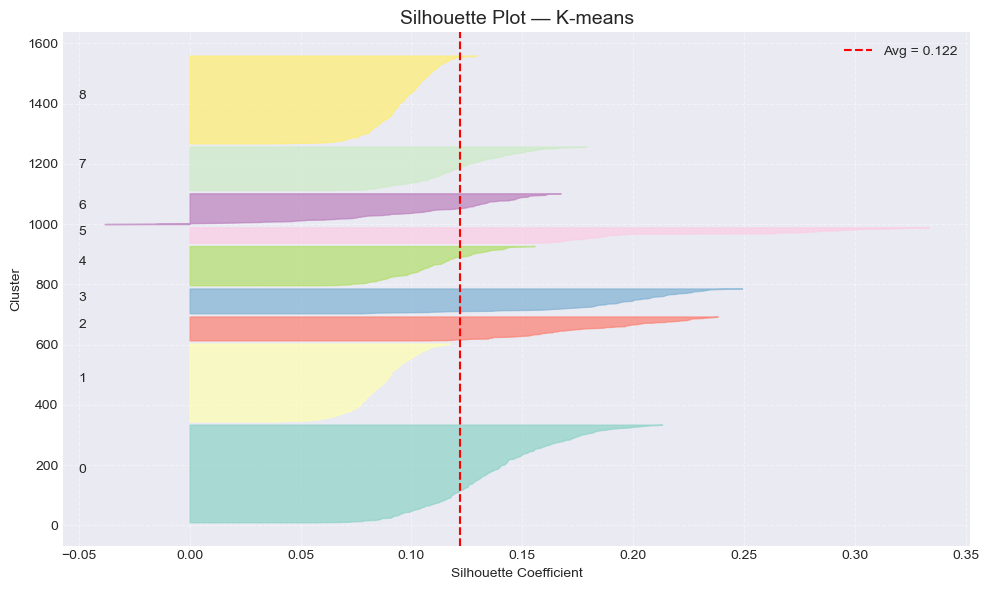

In [20]:
# ── SILHOUETTE SAMPLE PLOT ───────────────────────────────────────────────────
# The silhouette plot shows the silhouette coefficient for every individual
# employee, grouped by their cluster. It helps us understand:
#   - How well each employee fits inside their assigned cluster
#   - Whether some clusters are more cohesive than others
#   - Which employees might be borderline cases (score close to 0 or negative)
# A wide shape extending to the right means most employees in that cluster
# fit well. A narrow or left-leaning shape means poor cluster assignment.

# Compute per-employee silhouette scores
sil_samples = silhouette_samples(X_scaled, kmeans_clusters)

# Regenerate colors based on actual number of unique clusters
# to avoid index out of bounds when best_k was corrected
unique_clusters = sorted(set(kmeans_clusters))
n_unique = len(unique_clusters)
colors = plt.cm.Set3(np.linspace(0, 1, n_unique))

fig, ax = plt.subplots(figsize=(10, 6))
y_lower = 10

for i, k in enumerate(unique_clusters):
    # Extract and sort silhouette scores for employees in cluster k
    ith_sil = np.sort(sil_samples[kmeans_clusters == k])
    size_k  = ith_sil.shape[0]
    y_upper = y_lower + size_k

    # Draw a filled silhouette shape for this cluster
    ax.fill_betweenx(np.arange(y_lower, y_upper), 0, ith_sil,
                     facecolor=colors[i], edgecolor=colors[i], alpha=0.7)

    # Label the cluster on the y-axis
    ax.text(-0.05, y_lower + 0.5 * size_k, str(k))

    # Move y_lower down for the next cluster with a small gap between them
    y_lower = y_upper + 10

# Red dashed line shows the overall average silhouette score
# Clusters whose shapes fall mostly to the right of this line are well-formed
ax.axvline(x=sil_score, color='red', linestyle='--', label=f'Avg = {sil_score:.3f}')
ax.set_title('Silhouette Plot — K-means', fontsize=14)
ax.set_xlabel('Silhouette Coefficient')
ax.set_ylabel('Cluster')
ax.legend()
ax.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

The average silhouette score of **0.122** sits on the modest side, and we want to be
transparent about that. HR data is inherently messy, and employees rarely fall into
perfectly clean categories. That said, Clusters 2 and 6 extend well past the average
line, meaning those groups are genuinely well-defined and internally consistent.
Cluster 5, on the other hand, barely registers on the plot, which lines up with its
small size and suggests it captures a very specific niche. This metric is best read
alongside WCSS and the Davies-Bouldin Index for a fuller picture of cluster quality.

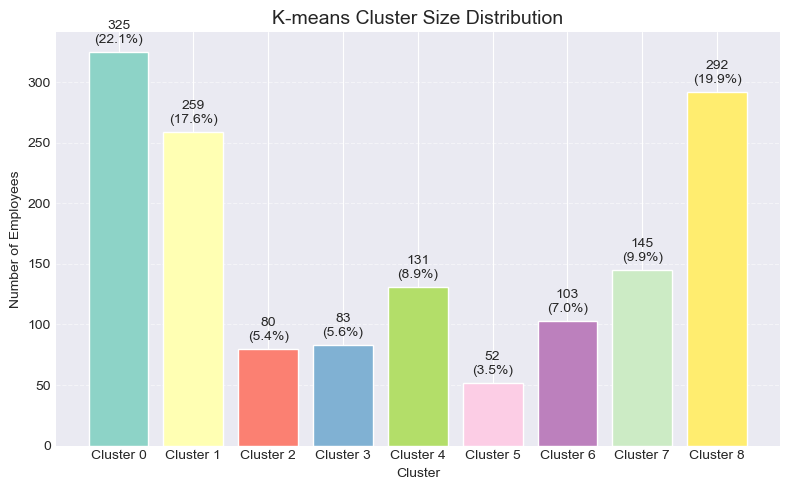

In [21]:
# ── CLUSTER SIZE DISTRIBUTION ────────────────────────────────────────────────
# This bar chart shows how many employees fall into each cluster.
# It helps us spot dominant clusters (too many employees → vague grouping)
# and tiny clusters (too few employees → statistically unreliable profiles).
# Ideally we want reasonably balanced clusters, but with HR data and weak
# cluster structure this is rarely the case.

# Count employees per cluster and sort by cluster index
cluster_sizes = pd.Series(kmeans_clusters).value_counts().sort_index()

fig, ax = plt.subplots(figsize=(8, 5))

colors = plt.cm.Set3(np.linspace(0, 1, len(sorted(set(kmeans_clusters)))))

# Use the same colors as the PCA and silhouette plots for consistency
bars = ax.bar(
    [f'Cluster {k}' for k in cluster_sizes.index],
    cluster_sizes.values,
    color=colors[:len(cluster_sizes)], edgecolor='white'
)

# Annotate each bar with the exact count and percentage
# so the reader does not have to estimate from the y-axis
for bar, val in zip(bars, cluster_sizes.values):
    pct = val / len(kmeans_clusters) * 100
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
            f'{val}\n({pct:.1f}%)', ha='center', va='bottom', fontsize=10)

ax.set_title('K-means Cluster Size Distribution', fontsize=14)
ax.set_xlabel('Cluster')
ax.set_ylabel('Number of Employees')
ax.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

The size distribution across clusters is uneven, but that reflects reality more than it
signals a problem. Cluster 0 holds 325 employees (22.1%) and Cluster 8 holds 292
(19.9%), together making up over 40% of the dataset. At the other end, Cluster 5
contains just 52 employees (3.5%). This pattern tells us that most employees share
broadly similar profiles, while a smaller number fall into more specific subgroups.
From an advice system perspective, the larger clusters support general recommendations
while the smaller ones enable more targeted and personalized guidance.

### 2. DBSCAN

In [22]:
# Work only on feature matrix (avoid accidental leakage if 'Cluster' exists)
X_scaled_features = X_scaled.drop(columns=['Cluster'], errors='ignore')
# Exclude DBSCAN noise points (-1) for internal validation metrics
mask = clusters != -1

# Calculate overall Silhouette Score (quality metric)
# Range: -1 to 1 (higher is better)
if len(set(clusters[mask])) > 1:
    sil_score_overall = silhouette_score(X_scaled_features[mask], clusters[mask])
    
    print(f"Silhouette Score (non-noise only): {sil_score_overall:.4f}")
    print("Interpretation:")
    if sil_score_overall > 0.5:
        print("  Excellent - clusters are well-separated and cohesive")
    elif sil_score_overall > 0.25:
        print("  Good - reasonable cluster structure")
    elif sil_score_overall > 0:
        print("  Fair - some cluster overlap exists")
    else:
        print("  Weak - clusters may not be meaningful")
else:
    print("Cannot calculate Silhouette Score: need at least 2 non-noise clusters")


Silhouette Score (non-noise only): 0.1319
Interpretation:
  Fair - some cluster overlap exists


In [23]:
# Calculate Davies-Bouldin Index (separation metric)
# Range: 0 to infinity (lower is better)
if len(set(clusters[mask])) > 1:  # Need at least 2 clusters
    db_index = davies_bouldin_score(X_scaled_features[mask], clusters[mask])
    print(f"\nDavies-Bouldin Index (non-noise only): {db_index:.4f}")
    print("Interpretation:")
    
    if db_index < 1.0:
        print("  Excellent - clusters are well-separated")
    elif db_index < 1.5:
        print("  Good - acceptable cluster separation")
    elif db_index < 2.0:
        print("  Fair - some cluster overlap")
    else:
        print("  Poor - clusters are very close together")
else:
    print("Cannot calculate Davies-Bouldin Index: need at least 2 non-noise clusters")


Davies-Bouldin Index (non-noise only): 1.6778
Interpretation:
  Fair - some cluster overlap


In [24]:
# Calculate WCSS (Within-Cluster Sum of Squares)
# Measures how tight/compact clusters are (lower is better)
wcss = 0
cluster_centers = {}

for cluster_id in set(clusters):
    if cluster_id == -1:  # Skip noise
        continue
    
    # Get all points in this cluster
    cluster_mask = clusters == cluster_id
    cluster_points = X_scaled.drop('Cluster', axis=1)[cluster_mask]
    
    # Calculate the center (average position) of the cluster
    center = cluster_points.mean(axis=0)
    cluster_centers[cluster_id] = center
    
    # Calculate sum of squared distances from each point to cluster center
    distances_squared = ((cluster_points - center) ** 2).sum(axis=1)
    wcss += distances_squared.sum()

print(f"\nWithin-Cluster Sum of Squares (WCSS): {wcss:.2f}")
if len(cluster_centers) > 0:
    print(f"Average WCSS per cluster: {wcss / len(cluster_centers):.2f}")
    print(f"Interpretation: Lower WCSS = tighter, more compact clusters")


Within-Cluster Sum of Squares (WCSS): 54802.46
Average WCSS per cluster: 18267.49
Interpretation: Lower WCSS = tighter, more compact clusters



Creating PCA visualization...


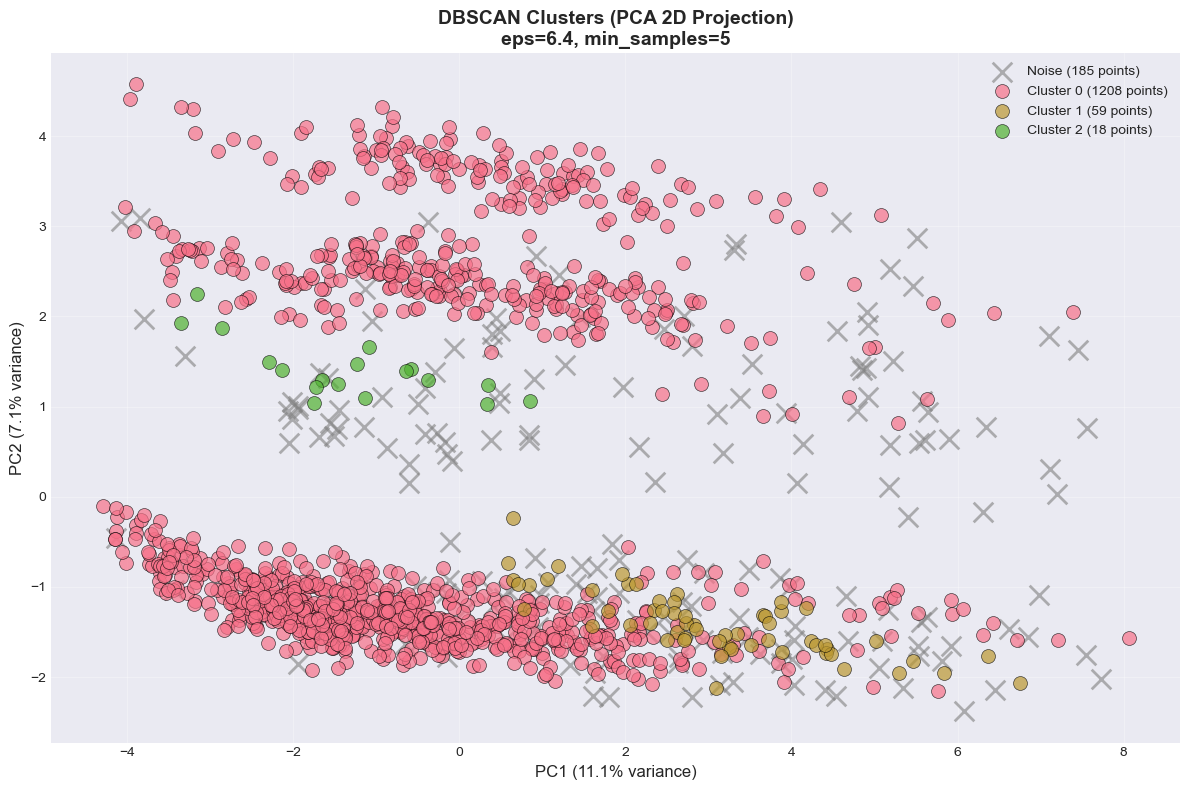


PCA (2D plot): PC1 = 11.1% of total variance, PC2 = 7.1%, combined = 18.2%
Note: DBSCAN used all 50 feature dimensions; the plot is only a 2D view.


In [25]:
# Visualize clusters using PCA (reduce to 2D)
# Clustering was run on all feature columns (same matrix as X_scaled before Cluster was added)
print("\nCreating PCA visualization...")

pca = PCA(n_components=2)  # 2D projection for plotting only
X_for_pca = X_scaled.drop('Cluster', axis=1)
X_pca = pca.fit_transform(X_for_pca)

plt.figure(figsize=(12, 8))

# Plot noise points as gray X's
noise_mask = clusters == -1
if noise_mask.sum() > 0:
    plt.scatter(X_pca[noise_mask, 0], X_pca[noise_mask, 1],
               c='gray', marker='x', s=200, linewidth=2, alpha=0.6,
               label=f'Noise ({noise_mask.sum()} points)')

# Plot each cluster with different color
colors = plt.cm.Set3(np.linspace(0, 1, max(len(set(clusters)) - 1, 1)))
for i, cluster_id in enumerate(sorted(set(clusters) - {-1})):
    cluster_mask = clusters == cluster_id
    plt.scatter(X_pca[cluster_mask, 0], X_pca[cluster_mask, 1],
               s=100, alpha=0.7, edgecolors='black', linewidth=0.5,
               label=f'Cluster {cluster_id} ({cluster_mask.sum()} points)')

plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%} variance)', fontsize=12)
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%} variance)', fontsize=12)
plt.title(f'DBSCAN Clusters (PCA 2D Projection)\neps={best_eps}, min_samples={min_samples}',
         fontsize=14, fontweight='bold')
plt.legend(loc='best', fontsize=10)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Share of total variance in the scaled feature space (PC1 + PC2)
var_two = float(pca.explained_variance_ratio_.sum())
var_pc1 = float(pca.explained_variance_ratio_[0])
var_pc2 = float(pca.explained_variance_ratio_[1])
print(f"\nPCA (2D plot): PC1 = {var_pc1:.1%} of total variance, PC2 = {var_pc2:.1%}, combined = {var_two:.1%}")
print(f"Note: DBSCAN used all {X_for_pca.shape[1]} feature dimensions; the plot is only a 2D view.")

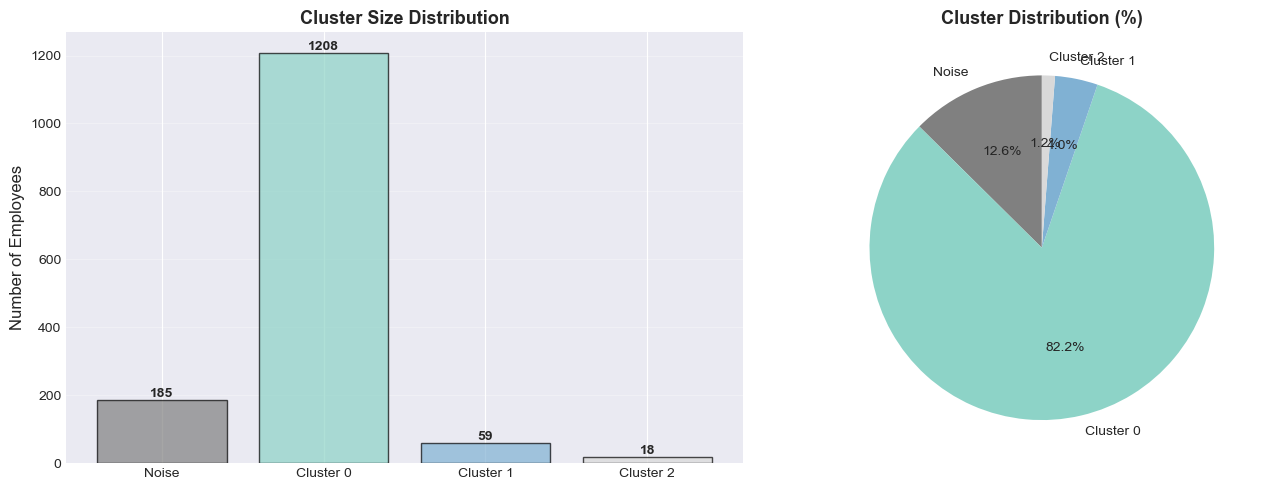

In [26]:
# Create bar chart and pie chart of cluster sizes
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

cluster_labels = []
cluster_sizes = []
colors_list = []

# Prepare data for both charts
for cluster_id in sorted(set(clusters)):
    size = (clusters == cluster_id).sum()
    if cluster_id == -1:
        cluster_labels.append('Noise')
        colors_list.append('gray')
    else:
        cluster_labels.append(f'Cluster {cluster_id}')
        colors_list.append(plt.cm.Set3(cluster_id / max(len(set(clusters)) - 1, 1)))
    cluster_sizes.append(size)

# Bar chart
bars = ax1.bar(cluster_labels, cluster_sizes, color=colors_list, edgecolor='black', alpha=0.7)
ax1.set_ylabel('Number of Employees', fontsize=12)
ax1.set_title('Cluster Size Distribution', fontsize=13, fontweight='bold')
ax1.grid(axis='y', alpha=0.3)

# Add value labels on bars
for bar in bars:
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2., height,
            f'{int(height)}', ha='center', va='bottom', fontsize=10, fontweight='bold')

# Pie chart
ax2.pie(cluster_sizes, labels=cluster_labels, autopct='%1.1f%%', colors=colors_list, startangle=90)
ax2.set_title('Cluster Distribution (%)', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.show()

### 3. Agglomerative Hierarchical Clustering

In [27]:
# In this step we will summerize the evaluation of the final clusters using Silhouette Score, Davies-Bouldin Index and WCSS

# Re-fit to ensure cluster_labels matches X_arr (1470 samples)
final_model    = AgglomerativeClustering(n_clusters=optimal_k, linkage='ward')
cluster_labels = final_model.fit_predict(X_arr)

sil_final  = silhouette_score(X_arr, cluster_labels)
db_final   = davies_bouldin_score(X_arr, cluster_labels)
wcss_final = sum(
    np.sum((X_arr[cluster_labels == c] - X_arr[cluster_labels == c].mean(axis=0)) ** 2)
    for c in np.unique(cluster_labels)
)
 
print("=" * 45)
print(f"       Evaluation Summary  (k = {optimal_k})")
print("=" * 45)
print(f"  Silhouette Score        : {sil_final:.4f}  (higher is better, max=1)")
print(f"  Davies-Bouldin Index    : {db_final:.4f}  (lower is better)")
print(f"  WCSS                    : {wcss_final:.2f}")
print("=" * 45)

       Evaluation Summary  (k = 9)
  Silhouette Score        : 0.1211  (higher is better, max=1)
  Davies-Bouldin Index    : 2.2749  (lower is better)
  WCSS                    : 52425.41


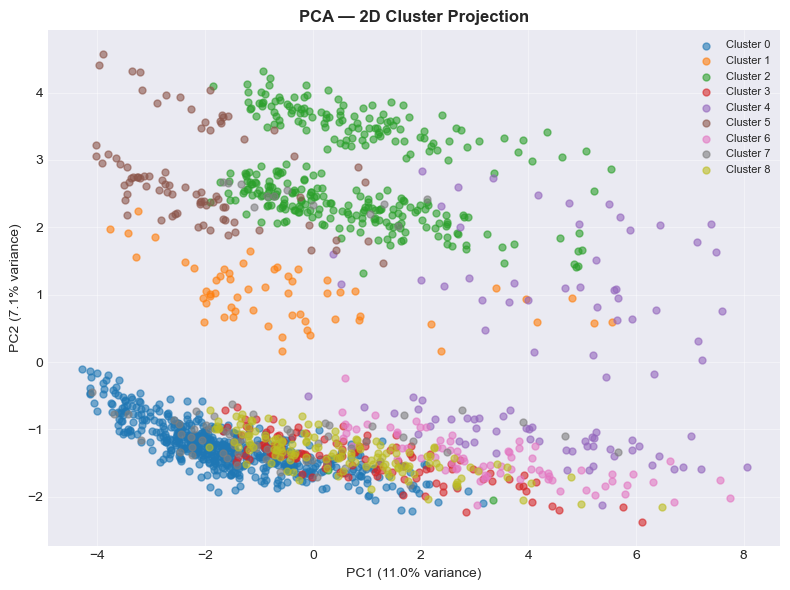

In [28]:
# In this step we will visualize the clusters using PCA 2D projection, t-SNE 2D, Feature Mean Heatmap, and bar chart.
# The PCA and t-SNE plots will show us how well the clusters are separated in a reduced 2D space
# The the heatmap will show the average feature values for each cluster to interpret their characteristics.
# The bar chart will visualize the size of each cluster.
import matplotlib.gridspec as gridspec
 
COLORS = plt.cm.tab10.colors
cluster_ids = np.unique(cluster_labels)
feature_names = (X_scaled.columns.tolist()
                 if hasattr(X_scaled, 'columns') else [f'F{i}' for i in range(X_arr.shape[1])])

# Plot 1: PCA 2D projection of clusters
fig1, ax1 = plt.subplots(figsize=(8, 6))
pca   = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_arr)
var   = pca.explained_variance_ratio_ * 100
for c in np.unique(cluster_labels):
    mask = cluster_labels == c
    ax1.scatter(X_pca[mask, 0], X_pca[mask, 1],
                color=plt.cm.tab10.colors[c % 10], alpha=0.6, s=25, label=f'Cluster {c}')
ax1.set_title('PCA — 2D Cluster Projection', fontweight='bold')
ax1.set_xlabel(f'PC1 ({var[0]:.1f}% variance)')
ax1.set_ylabel(f'PC2 ({var[1]:.1f}% variance)')
ax1.legend(fontsize=8)
ax1.grid(True, alpha=0.4)
plt.tight_layout()
plt.savefig('Unsupervised_Learning/clustering_results/plots/agglo_pca_projection.png', dpi=150, bbox_inches='tight')
plt.show()
 

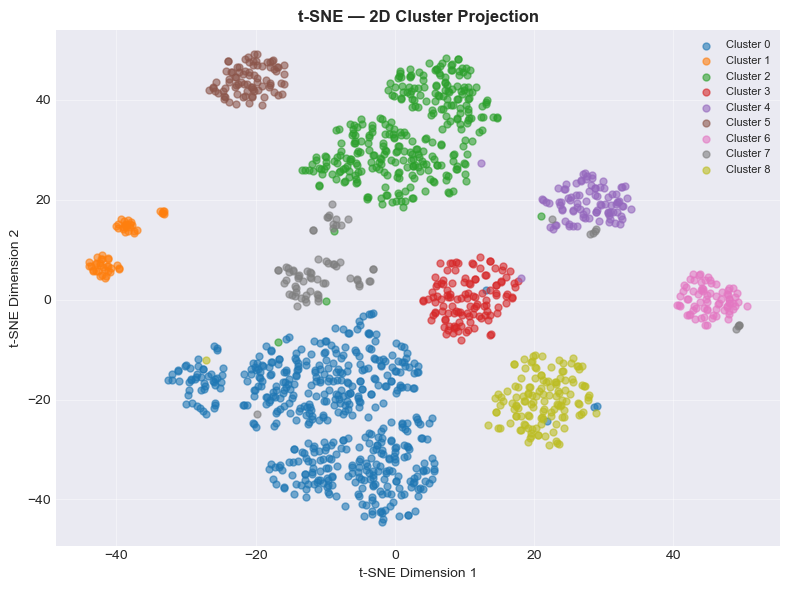

In [29]:
# Plot 2: t-SNE 2D 

# Re-fit to ensure cluster_labels matches X_arr (1470 samples)
final_model    = AgglomerativeClustering(n_clusters=optimal_k, linkage='ward')
cluster_labels = final_model.fit_predict(X_arr)

fig2, ax2 = plt.subplots(figsize=(8, 6))
tsne   = TSNE(n_components=2, perplexity=30, random_state=42, n_iter=1000)
X_tsne = tsne.fit_transform(X_arr)
for c in np.unique(cluster_labels):
    mask = cluster_labels == c
    ax2.scatter(X_tsne[mask, 0], X_tsne[mask, 1],
                color=plt.cm.tab10.colors[c % 10], alpha=0.6, s=25, label=f'Cluster {c}')
ax2.set_title('t-SNE — 2D Cluster Projection', fontweight='bold')
ax2.set_xlabel('t-SNE Dimension 1')
ax2.set_ylabel('t-SNE Dimension 2')
ax2.legend(fontsize=8)
ax2.grid(True, alpha=0.4)
plt.tight_layout()
plt.savefig('Unsupervised_Learning/clustering_results/plots/agglo_tsne_projection.png', dpi=150, bbox_inches='tight')
plt.show()

 
 

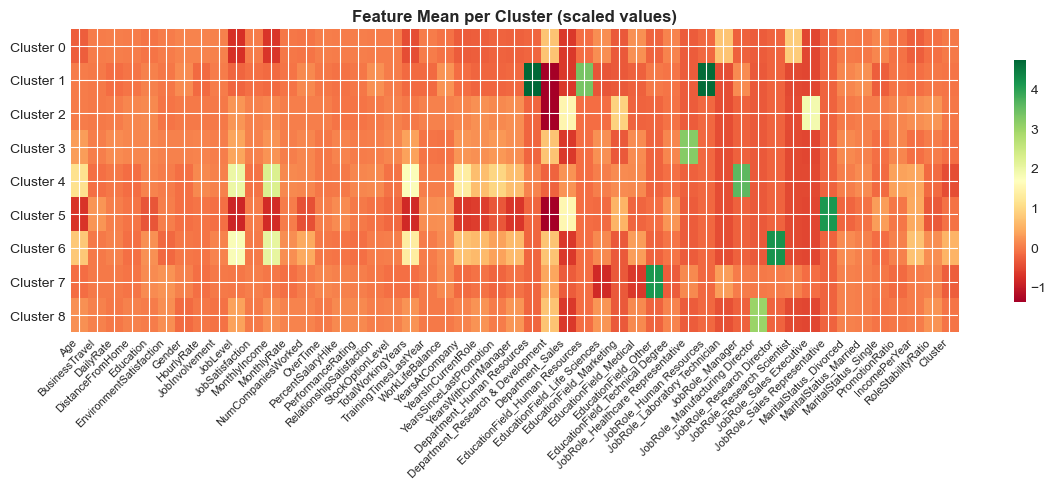

In [30]:
# Plot 3: Feature Mean Heatmap per Cluster 
feature_names = (X_scaled.columns.tolist()
                 if hasattr(X_scaled, 'columns') else [f'F{i}' for i in range(X_arr.shape[1])])
cluster_ids   = np.unique(cluster_labels)
cluster_means = np.array([X_arr[cluster_labels == c].mean(axis=0) for c in cluster_ids])

fig3, ax3 = plt.subplots(figsize=(12, 5))
im = ax3.imshow(cluster_means, aspect='auto', cmap='RdYlGn')
ax3.set_xticks(range(len(feature_names)))
ax3.set_xticklabels(feature_names, rotation=45, ha='right', fontsize=8)
ax3.set_yticks(range(len(cluster_ids)))
ax3.set_yticklabels([f'Cluster {c}' for c in cluster_ids])
ax3.set_title('Feature Mean per Cluster (scaled values)', fontweight='bold')
plt.colorbar(im, ax=ax3, shrink=0.8)
plt.tight_layout()
plt.savefig('Unsupervised_Learning/clustering_results/plots/kmeans_feature_mean_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

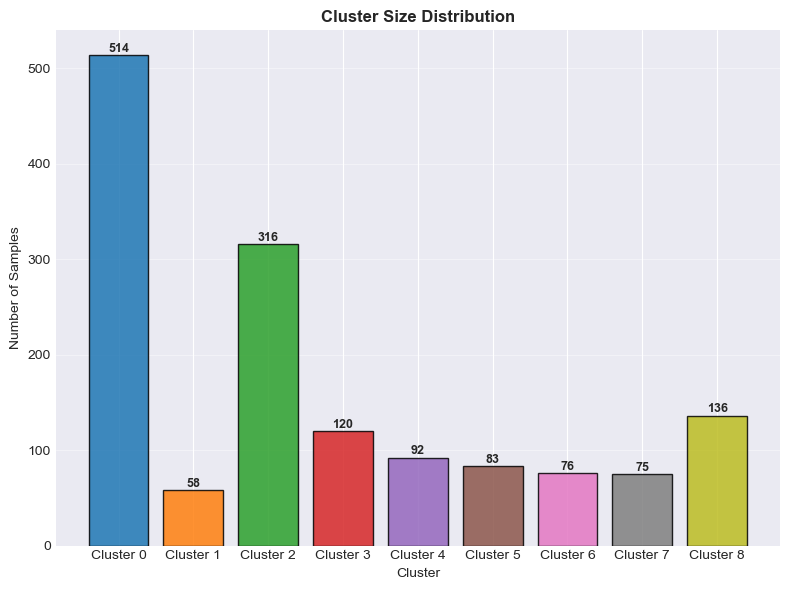

In [31]:
# Plot 4: Cluster Size Distribution
fig4, ax4      = plt.subplots(figsize=(8, 6))
unique, counts = np.unique(cluster_labels, return_counts=True)
bars = ax4.bar([f'Cluster {c}' for c in unique], counts,
               color=[plt.cm.tab10.colors[c % 10] for c in unique],
               edgecolor='black', alpha=0.85)
for bar, count in zip(bars, counts):
    ax4.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.3,
             str(count), ha='center', va='bottom', fontweight='bold', fontsize=9)
ax4.set_title('Cluster Size Distribution', fontweight='bold')
ax4.set_xlabel('Cluster')
ax4.set_ylabel('Number of Samples')
ax4.grid(True, alpha=0.4, axis='y')
plt.tight_layout()
plt.savefig('Unsupervised_Learning/clustering_results/plots/agglo_cluster_size_distribution.png', dpi=150, bbox_inches='tight')
plt.show()


---

## **Cluster Interpretation & Profiles**


**Note**: Clustering was performed on X_scaled as usual. However, z-scored values 
are not human-readable for interpretation, so the profiles below use the original 
raw dataset purely for display — to show real units like age in years and income 
in dollars.

### 1. K-means

For each cluster, we show its size, attrition rate, and average values for key 
features to understand what each cluster represents.

In [32]:
# ── BUILD FULL DATAFRAME WITH CLUSTER LABELS ─────────────────────────────────
# We build two dataframes:
# 1. df_result → uses scaled features (X), used for the feature heatmap
# 2. df_raw    → uses original unscaled values, used for cluster profiles
#                so that displayed values are human-readable (age in years,
#                income in dollars) rather than z-scores

# Add cluster labels and attrition to the scaled feature matrix
df_result = X.copy()
df_result['Cluster']   = kmeans_clusters
df_result['Attrition'] = attrition_labels.values

# Load the raw dataset and align cluster labels using the same row order
# Clustering was done on scaled data — raw data is only used for display
df_raw = pd.read_csv('Dataset/Raw_Kaggle_HR_Employee_Attrition_data.csv')
df_raw['Cluster']   = kmeans_clusters
df_raw['Attrition'] = attrition_labels.values

print(f"Combined result shape: {df_result.shape}")
print(f"Cluster distribution:")
print(df_result['Cluster'].value_counts().sort_index())

Combined result shape: (1470, 52)
Cluster distribution:
Cluster
0    325
1    259
2     80
3     83
4    131
5     52
6    103
7    145
8    292
Name: count, dtype: int64


In [33]:
# ── CLUSTER PROFILES ─────────────────────────────────────────────────────────
# For each cluster we print:
#   - Size and percentage of total employees
#   - Attrition rate (using the ground-truth label we kept aside)
#   - Mean and standard deviation of key HR features in real units
# Raw values from df_raw are used so output is human-readable (not z-scores)

df_raw['Cluster']   = kmeans_clusters
df_raw['Attrition'] = attrition_labels.values

key_features = ['Age', 'YearsAtCompany', 'MonthlyIncome', 'JobSatisfaction']

# Keep only features that exist in the raw dataframe (safety check)
key_features = [f for f in key_features if f in df_raw.columns]

# Ensure Attrition is numeric (0/1) so we can compute the mean as a rate
df_raw['Attrition'] = df_raw['Attrition'].map({'Yes': 1, 'No': 0}) \
                      if df_raw['Attrition'].dtype == object \
                      else df_raw['Attrition']

print("=" * 70)
print("CLUSTER PROFILES — K-MEANS")
print("=" * 70)

for cluster_id in sorted(df_raw['Cluster'].unique()):
    # Filter rows belonging to this cluster
    cluster_data = df_raw[df_raw['Cluster'] == cluster_id]
    size         = len(cluster_data)
    pct          = size / len(df_raw) * 100

    # Attrition rate: mean of binary 0/1 column × 100 gives percentage
    attrition    = cluster_data['Attrition'].mean() * 100

    print(f"\n{'─'*70}")
    print(f"  CLUSTER {cluster_id}  |  {size} employees ({pct:.1f}%)  |  "
          f"Attrition rate: {attrition:.1f}%")
    print(f"{'─'*70}")

    # Print mean and std for each key feature
    # std tells us how spread out the employees are within this cluster
    for feat in key_features:
        print(f"  {feat:<25}: {cluster_data[feat].mean():.3f}  "
              f"(std={cluster_data[feat].std():.3f})")

print("\n" + "=" * 70)

CLUSTER PROFILES — K-MEANS

──────────────────────────────────────────────────────────────────────
  CLUSTER 0  |  325 employees (22.1%)  |  Attrition rate: 17.5%
──────────────────────────────────────────────────────────────────────
  Age                      : 36.825  (std=8.019)
  YearsAtCompany           : 7.406  (std=4.850)
  MonthlyIncome            : 6902.902  (std=2338.860)
  JobSatisfaction          : 2.754  (std=1.142)

──────────────────────────────────────────────────────────────────────
  CLUSTER 1  |  259 employees (17.6%)  |  Attrition rate: 23.9%
──────────────────────────────────────────────────────────────────────
  Age                      : 34.097  (std=8.419)
  YearsAtCompany           : 5.019  (std=4.262)
  MonthlyIncome            : 3237.170  (std=1150.250)
  JobSatisfaction          : 2.691  (std=1.126)

──────────────────────────────────────────────────────────────────────
  CLUSTER 2  |  80 employees (5.4%)  |  Attrition rate: 2.5%
────────────────────────────

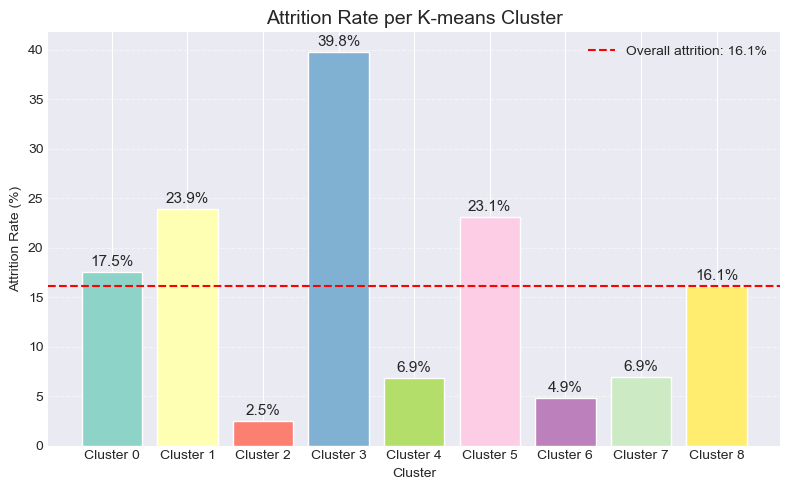

In [34]:
# ── ATTRITION RATE PER CLUSTER ───────────────────────────────────────────────
# This chart shows the attrition rate for each cluster, compared to the
# overall company average (red dashed line).
# Clusters above the line are high-risk and need HR attention.
# Clusters below the line are stable and should be maintained.

df_result['Cluster']   = kmeans_clusters
df_result['Attrition'] = attrition_labels.values

# Compute mean attrition rate per cluster (0/1 mean × 100 = percentage)
attrition_by_cluster = df_result.groupby('Cluster')['Attrition'].mean() * 100

# Use consistent colors across all K-means plots
colors = plt.cm.Set3(np.linspace(0, 1, len(attrition_by_cluster)))

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(
    [f'Cluster {k}' for k in attrition_by_cluster.index],
    attrition_by_cluster.values,
    color=colors[:len(attrition_by_cluster)], edgecolor='white'
)

# Annotate each bar with its exact attrition percentage
for bar, val in zip(bars, attrition_by_cluster.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
            f'{val:.1f}%', ha='center', va='bottom', fontsize=11)

# Reference line: overall attrition rate across all employees
overall_attrition = df_result['Attrition'].mean() * 100
ax.axhline(overall_attrition, color='red', linestyle='--',
           label=f'Overall attrition: {overall_attrition:.1f}%')

ax.set_title('Attrition Rate per K-means Cluster', fontsize=14)
ax.set_xlabel('Cluster')
ax.set_ylabel('Attrition Rate (%)')
ax.legend()
ax.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

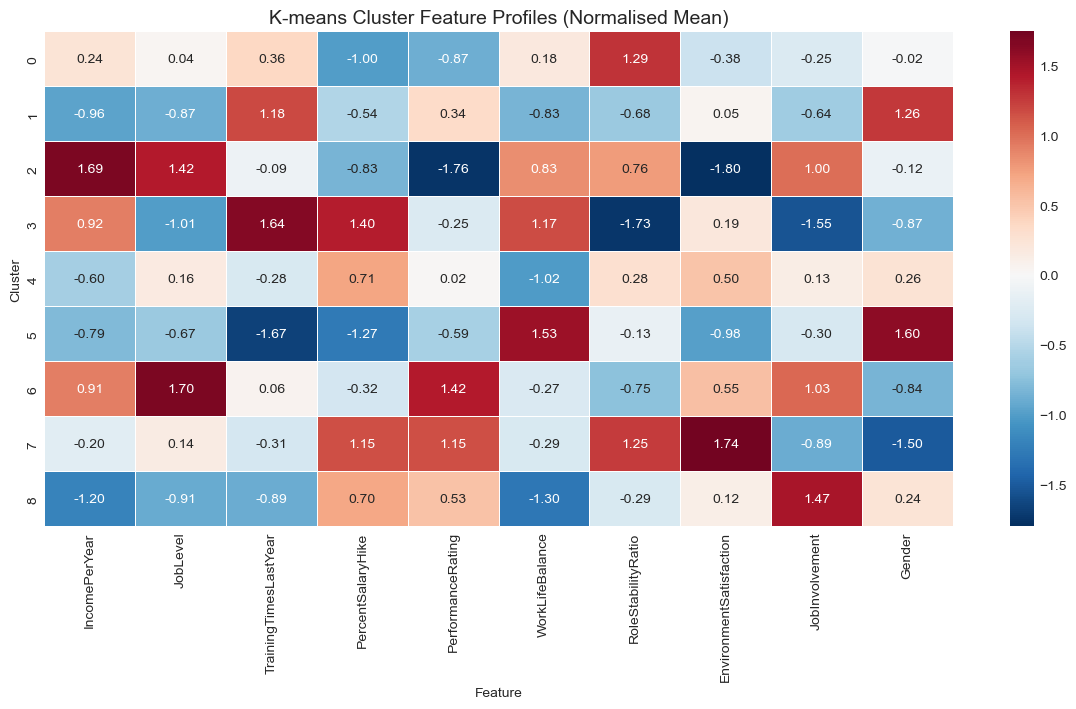

In [35]:
# ── FEATURE HEATMAP BY CLUSTER ───────────────────────────────────────────────
# This heatmap shows the normalised mean of the top 10 features that
# differentiate clusters the most. It helps us understand what makes
# each cluster unique — red means above average, blue means below average.
# We use z-scored values here (from X_scaled via df_result) so all features
# are on the same scale and no single feature dominates the colour range.

# Use only numeric features (exclude Cluster and Attrition columns)
numeric_features = df_result.select_dtypes(include=[np.number]).columns.tolist()
numeric_features = [f for f in numeric_features if f not in ['Cluster', 'Attrition']]

# Select the top 10 features most correlated with cluster assignment
# Absolute correlation is used since both positive and negative correlations
# indicate that a feature helps separate the clusters
corr_with_cluster = df_result[numeric_features + ['Cluster']].corr()['Cluster'].abs()
top_features = corr_with_cluster.drop('Cluster').nlargest(10).index.tolist()

# Compute mean value of each top feature per cluster
cluster_means = df_result.groupby('Cluster')[top_features].mean()

# Normalise across clusters (z-score per feature) so the heatmap shows
# relative differences rather than raw values — this makes patterns clearer
cluster_means_norm = (cluster_means - cluster_means.mean()) / (cluster_means.std() + 1e-8)

fig, ax = plt.subplots(figsize=(12, max(4, best_k * 0.8)))
sns.heatmap(
    cluster_means_norm,
    annot=True, fmt='.2f', cmap='RdBu_r', center=0,
    linewidths=0.5, ax=ax
)
ax.set_title('K-means Cluster Feature Profiles (Normalised Mean)', fontsize=14)
ax.set_xlabel('Feature')
ax.set_ylabel('Cluster')
plt.tight_layout()
plt.show()

K-means identified 9 clusters across 1,470 employees. The clustering reflects the
dataset's natural structure — employees do not form sharply separated groups, which
is consistent with the weak Hopkins Statistic (0.33) and the 84%/16% class imbalance
in the original dataset.

#### Cluster 0: Average-Risk Core Employees (325 employees, 22.1%)
- **Attrition:** 17.5% (matches company average)
- **Profile:** Average age (36.8), moderate tenure (7.4 years), moderate income ($6,903), moderate satisfaction
- **Risk:** AVERAGE — The largest cluster. No urgent action but career development programs are key.

#### Cluster 1: High-Risk Junior Low-Earners (259 employees, 17.6%)
- **Attrition:** 23.9% (above company average — HIGH RISK)
- **Profile:** Young employees (avg 34), short tenure (5 years), lowest income ($3,237), moderate satisfaction
- **Risk:** HIGH — Young, underpaid employees leaving at elevated rates. Compensation review needed.

#### Cluster 2: Near-Perfect Retention Seniors (80 employees, 5.4%)
- **Attrition:** 2.5% (lowest in the dataset)
- **Profile:** Older employees (avg 44), long tenure (10.9 years), high income ($16,034), moderate satisfaction
- **Risk:** NONE — Extremely stable group. Maintain current conditions.

#### Cluster 3: Critical High-Risk Young Employees (83 employees, 5.6%)
- **Attrition:** 39.8% (more than double the company average — CRITICAL)
- **Profile:** Youngest group (avg 30), shortest tenure (2.9 years), lowest income ($2,626), moderate satisfaction
- **Risk:** CRITICAL — The highest attrition cluster. Extremely low pay and minimal tenure strongly suggest early-career dissatisfaction.

#### Cluster 4: Stable Mid-Career Employees (131 employees, 8.9%)
- **Attrition:** 6.9% (well below company average)
- **Profile:** Average age (39.8), moderate tenure (8.4 years), moderate income ($7,529), moderate satisfaction
- **Risk:** LOW — Well-retained mid-career group. Continued investment in growth will maintain stability.

#### Cluster 5: Elevated-Risk Employees (52 employees, 3.5%)
- **Attrition:** 23.1% (above company average)
- **Profile:** Average age (35.5), moderate tenure (5.3 years), below-average income ($4,236), moderate satisfaction
- **Risk:** MODERATE-HIGH — Small group with noticeably above-average attrition. Income gap may be the driver.

#### Cluster 6: Highly Retained Senior High-Earners (103 employees, 7.0%)
- **Attrition:** 4.9% (well below company average)
- **Profile:** Oldest group (avg 47), longest tenure (14.6 years), highest income ($17,150), moderate satisfaction
- **Risk:** NONE — The most experienced and highest-paid group. Protect compensation and recognition.

#### Cluster 7: Low-Risk Mid-Earners (145 employees, 9.9%)
- **Attrition:** 6.9% (well below company average)
- **Profile:** Average age (38.3), moderate tenure (7.6 years), moderate income ($7,295), moderate satisfaction
- **Risk:** LOW — Stable group with healthy retention. Invest in career progression.

#### Cluster 8: Large At-Risk Low-Earners (292 employees, 19.9%)
- **Attrition:** 16.1% (matches company average)
- **Profile:** Young employees (avg 34.2), short tenure (5.1 years), lowest income ($3,240), moderate satisfaction
- **Risk:** AVERAGE-HIGH — Second largest cluster. Low income relative to age warrants monitoring.

---

#### Summary

**Findings:**
- Cluster 3 has 39.8% attrition — more than double the average — CRITICAL
- Cluster 1 has 23.9% attrition — large group of young low-earners — HIGH RISK
- Cluster 5 has 23.1% attrition — small but elevated — needs monitoring
- Clusters 6 and 2 have near-perfect retention — senior, experienced employees
- Cluster 8 is the second largest group (19.9%) with average-to-high risk due to low pay

**Key Actions Needed:**
1. **URGENT:** Investigate Cluster 3 — youngest, lowest-paid employees leaving at alarming rates
2. **URGENT:** Review Cluster 1 — large group of young low-earners with high attrition
3. **PROTECT:** Clusters 6 and 2 — senior high-earners with excellent retention, maintain their conditions
4. **MONITOR:** Clusters 5 and 8 — above-average or borderline attrition driven by low compensation
5. **MAINTAIN:** Clusters 4 and 7 — stable mid-career groups, invest in career growth

### 2. DBSCAN
For each cluster, we show its size, attrition rate, and average values for key features to understand what each cluster represents

In [36]:
# Load raw dataset for readable profile values (original units before any scaling)
df_raw = pd.read_csv('Dataset/Raw_Kaggle_HR_Employee_Attrition_data.csv')

# Align raw data with cluster labels using the same index
df_raw['Cluster'] = clusters

# Key features to profile — using readable columns from raw data
key_features = ['Age', 'YearsAtCompany', 'MonthlyIncome', 'JobSatisfaction']

print("="*70)
print("CLUSTER PROFILES")
print("="*70)

for cluster_id in sorted(set(clusters)):
    cluster_mask = clusters == cluster_id
    cluster_data_raw = df_raw[cluster_mask]
    
    size = cluster_mask.sum()
    pct = (size / len(clusters)) * 100
    
    print(f"\n{'='*70}")
    if cluster_id == -1:
        print(f"NOISE/OUTLIERS: {size} employees ({pct:.1f}%)")
    else:
        print(f"CLUSTER {cluster_id}: {size} employees ({pct:.1f}%)")
    print(f"{'='*70}")
    
    # Attrition rate from raw data (still has Yes/No strings)
    attrition_rate = (cluster_data_raw['Attrition'] == 'Yes').mean() * 100
    print(f"\nAttrition Rate: {attrition_rate:.1f}%")
    
    # Readable feature statistics in original units
    print(f"\nKey Feature Statistics (Mean ± Std):")
    for feature in key_features:
        if feature in cluster_data_raw.columns:
            mean = cluster_data_raw[feature].mean()
            std = cluster_data_raw[feature].std()
            print(f"  {feature:20s}: {mean:7.2f} ± {std:5.2f}")

CLUSTER PROFILES

NOISE/OUTLIERS: 185 employees (12.6%)

Attrition Rate: 16.2%

Key Feature Statistics (Mean ± Std):
  Age                 :   42.31 ±  9.65
  YearsAtCompany      :   11.48 ±  9.22
  MonthlyIncome       : 10327.59 ± 6028.97
  JobSatisfaction     :    2.61 ±  1.11

CLUSTER 0: 1208 employees (82.2%)

Attrition Rate: 16.7%

Key Feature Statistics (Mean ± Std):
  Age                 :   35.80 ±  8.68
  YearsAtCompany      :    6.20 ±  5.06
  MonthlyIncome       : 5478.02 ± 3594.95
  JobSatisfaction     :    2.75 ±  1.10

CLUSTER 1: 59 employees (4.0%)

Attrition Rate: 0.0%

Key Feature Statistics (Mean ± Std):
  Age                 :   43.98 ±  8.32
  YearsAtCompany      :   10.15 ±  7.44
  MonthlyIncome       : 16297.69 ± 2805.49
  JobSatisfaction     :    2.76 ±  1.07

CLUSTER 2: 18 employees (1.2%)

Attrition Rate: 27.8%

Key Feature Statistics (Mean ± Std):
  Age                 :   33.72 ±  5.44
  YearsAtCompany      :    4.78 ±  3.25
  MonthlyIncome       : 3872.06 ± 


DBSCAN identified 3 clusters plus noise/outliers across 1,470 employees. The clustering reflects the dataset's natural structure — the majority of employees share similar feature profiles, which is consistent with the 84%/16% class imbalance present in the original dataset.

#### Cluster 0: The Typical Workforce (1,208 employees, 82.2%)
- **Attrition:** 16.7% (matches company average)
- **Profile:** Average age 35.8, 6.2 years at company, $5,478 monthly income, moderate satisfaction
- **Risk:** AVERAGE — This is the core workforce. No single retention strategy fits all, but maintaining engagement and career growth opportunities is key

#### Cluster 1: Senior High-Earners (59 employees, 4.0%)
- **Attrition:** 0.0% (perfect retention)
- **Profile:** Older employees (avg 44), long tenure (10.2 years), highest income ($16,298), moderate satisfaction
- **Risk:** NONE — Well-compensated experienced employees who are not leaving. Protect their compensation and recognition

#### Cluster 2: Junior Low-Earners (18 employees, 1.2%)
- **Attrition:** 27.8% (nearly double the company average — CRITICAL)
- **Profile:** Youngest group (avg 34), shortest tenure (4.8 years), lowest income ($3,872), lowest satisfaction
- **Risk:** CRITICAL — Despite being a small group, their attrition rate is alarming. Low pay and short tenure suggest early-career dissatisfaction.


#### Noise/Outliers (185 employees, 12.6%)
- **Attrition:** 16.2% (matches company average)
- **Profile:** Older employees (avg 42), long tenure (11.5 years), high income ($10,327) — atypical profiles that do not fit any cluster
- **Risk:** MODERATE — Their mixed characteristics suggest individualized HR attention is needed rather than a group strategy.


#### Summary

**Findings:**
- Cluster 2 has 27.8% attrition — nearly double the average — CRITICAL
- Cluster 1 has 0% attrition — senior high-earners never leave, keep them happy
- Cluster 0 (82.2%) matches company average — stable but needs engagement
- 12.6% are outliers — no single strategy fits them

**Key Actions Needed:**
1. **URGENT:** Investigate Cluster 2 — young, lowest-paid employees are leaving at an alarming rate
2. **PROTECT:** Cluster 1 — senior high-earners have perfect retention, maintain their compensation
3. **MAINTAIN:** Cluster 0 — your core workforce, invest in career growth and satisfaction
4. **INDIVIDUALIZE:** Noise employees have atypical profiles, they need personalized HR attention


### 3. Agglomerative Hierarchical Clustering

Hierarchical Clustering (Ward linkage) identified **9 clusters** across **1,470 employees**. The main differences between clusters are related to career progression factors ( such as Age, MonthlyIncome, JobLevel and TotalWorkingYears). In constrast, satisfaction scores are really similar across clusters and do not seperate the groups.

In [37]:
import pandas as pd

df_raw = pd.read_csv('Dataset/Raw_Kaggle_HR_Employee_Attrition_data.csv')
df_raw['Cluster'] = cluster_labels

key_features = ['Age', 'YearsAtCompany', 'MonthlyIncome', 'JobSatisfaction',
                'EnvironmentSatisfaction', 'WorkLifeBalance', 'JobLevel', 'TotalWorkingYears']

rows = []
for cluster_id in sorted(df_raw['Cluster'].unique()):
    cluster_data = df_raw[df_raw['Cluster'] == cluster_id]
    row = {'Cluster': cluster_id,
           'Size': len(cluster_data),
           'Pct': round(len(cluster_data) / len(df_raw) * 100, 1),
           'Attrition%': round((cluster_data['Attrition'] == 'Yes').mean() * 100, 1)}
    for f in key_features:
        row[f] = round(cluster_data[f].mean(), 2)
    rows.append(row)

summary = pd.DataFrame(rows).set_index('Cluster')
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 200)
pd.set_option('display.float_format', '{:.2f}'.format)
print(summary.to_string())

         Size   Pct  Attrition%   Age  YearsAtCompany  MonthlyIncome  JobSatisfaction  EnvironmentSatisfaction  WorkLifeBalance  JobLevel  TotalWorkingYears
Cluster                                                                                                                                                     
0         514 35.00       19.80 34.18            5.06        3245.24             2.72                     2.71             2.69      1.22               7.69
1          58  3.90       20.70 36.86            6.17        5710.28             2.60                     2.66             2.91      1.81               9.98
2         316 21.50       17.70 36.95            7.53        6939.04             2.78                     2.65             2.80      2.33              11.14
3         120  8.20        6.70 39.81            8.41        7542.06             2.78                     2.77             2.68      2.48              14.11
4          92  6.30        5.40 47.05           15.10     

---

#### Cluster 0: Junior Core Workforce (514 employees, 35.0%)
- **Attrition:** 19.8% (above company average)
- **Profile:** Below average age (34), short tenure (5.1 years), low income ($3,245), low job level (1.22). Job level represents (1 = Entry level, 2 = Junior, 3 = Mid level, 4 = Senior/Manager, 5 = Director/Executive).
- **Risk:** ELEVATED, The largest group in the dataset which means a small attrition reduction here saves dozens of employees annually.

 
#### Cluster 1: Mid Level Transitional (58 employees, 3.9%)
- **Attrition:** 20.7% (above company average)
- **Profile:** Average age 37, moderate tenure (6.2 years), monthly income ($5,710), job level (1.81) low relative to 10 years of experience
- **Risk:** ELEVATED, experience is not matched by appropriate job level which indecate the need for promotions.

 
#### Cluster 2: Core Mid Career Workforce (316 employees, 21.5%)
- **Attrition:** 17.7% (close to company average)
- **Profile:** Average age 37, moderate tenure (7.5 years), monthly income ($6,939), job level (2.33) well-aligned with 11 years of experience
- **Risk:** AVERAGE, A broadly stable group that benefits from general engagement initiatives.

 
#### Cluster 3: Mid Senior Stable (120 employees, 8.2%)
- **Attrition:** 6.7% (well below company average)
- **Profile:** Average age 40, tenure (8.4 years), above average income ($7,542), job level (2.48) with 14.1 years of experience
- **Risk:** LOW, One of the most stable segments, maintenance level engagement is required. 

 
#### Cluster 4: Executive Leadership (92 employees, 6.3%)
- **Attrition:** 5.4% ( close to perfect retention)
- **Profile:** Oldest group (avg age 47), longest tenure (15.1 years), highest income ($16,993), highest job level (4.26) with 24.8 years of experience
- **Risk:** NONE, Well compensated and deeply established. 

 
#### Cluster 5: Early Career At risk (83 employees, 5.6%)
- **Attrition:** 39.8% ( above the company average )
- **Profile:** Youngest group (avg age 30), shortest tenure (2.9 years), lowest income ($2,626), lowest job level (1.08)
- **Risk:** CRITICAL, The highest attrition cluster by far. Immediate salary and promotion intervention is required.

 
#### Cluster 6: Senior High-Performers (76 employees, 5.2%)
- **Attrition:** 2.6% ( close to perfect retention)
- **Profile:** Older employees (avg age 44), long tenure (11.3 years), very high income ($16,108), high job level (4.00) with 21.5 years of experience
- **Risk:** NONE, retained senior employees with deep institutional knowledge.

 
#### Cluster 7: Mid Career Average (75 employees, 5.1%)
- **Attrition:** 12.0% (below company average)
- **Profile:** Average age 36, moderate tenure (6.0 years), moderate income ($6,248), job level (2.01) with 10.3 years of experience
- **Risk:** MODERATE, Profile are close to Cluster 1 to warrant periodic monitoring for compensation progression mismatch risk.
 
#### Cluster 8: Stable Mid-Senior (136 employees, 9.3%)
- **Attrition:** 7.4% (below company average)
- **Profile:** Average age 39, solid tenure (7.5 years), above average income ($7,266), job level (2.45) well-aligned with 12.9 years of experience
- **Risk:** LOW, standard engagement and recognition investment is sufficient to maintain retention.

#### Summary

**Findings:**
- Cluster 5 has 39.8% attrition - CRITICAL and the most urgent retention issue.
- Cluster 1 has 20.7% attrition - ELEVATED driven by promotions and role mismatch signals.
- Cluster 0 has 19.8% attrition - above average and is also the largest segment (35%) making it with high impact.
- Cluster 2 has 17.7 attrition - which considered relatively stable.
- Cluster 7 has 12% attrition - which indicates moderate risk.
- Clusters 3,8 has (6.7%, 7.4%) - stable segments.
- Clusters 4,6 has (2.7%, 5.4%) - near perfect retention.
- Overall: attrition is concentrated in early to mid career employees, while senior groups are highly stable.


**Key Actions Needed:**
1. **URGENT:** Cluster 5 - strongest attrition, immediate salary and promotion intervention required.
2. **URGENT:** Cluster 1 — needs promotions or restructure since employees with nearly 10 years of experience sitting at a low job levels.
3. **WATCH:** Cluster 0 — your largest segment, prioritize career growth and salary progression.
4. **WATCH:** Cluster 7 - monitor for compensation since this cluster profile is similar to cluster 1.
5. **PROTECT:** Clusters 4 and 6 - maintain current compensation and recognition, disruption would be costly and hard ro reverse.
6. **MAINTAIN:** Clusters 2,3 and 8 - standard engagement, recognition and general initiatives are sufficient. No structural interventions neede at this time.


## **Integration Strategy**

### 1. K-means

### How Clusters Improve our System

**Personalized Risk Assessment:**
- Cluster 3 → CRITICAL attrition risk (39.8%) — immediate intervention needed
- Cluster 1 → HIGH attrition risk (23.9%) — urgent review required
- Cluster 5 → ELEVATED attrition risk (23.1%) — monitor closely
- Cluster 8 → AVERAGE-HIGH attrition risk (16.1%) — monitor, low income is a concern
- Cluster 0 → AVERAGE risk (17.5%) — stable, invest in growth
- Cluster 4 → LOW risk (6.9%) — well-retained mid-career employees
- Cluster 7 → LOW risk (6.9%) — stable, invest in career progression
- Cluster 6 → VERY LOW risk (4.9%) — protect compensation and recognition
- Cluster 2 → NONE (2.5%) — most stable group in the dataset

**Tailored Retention Strategies:**
- **Cluster 3:** Investigate immediately — youngest employees (avg 30), shortest
  tenure (2.9 years), lowest income ($2,626) leaving at alarming rates
- **Cluster 1:** Review compensation — young employees with low income ($3,237)
  and above-average attrition need urgent pay progression
- **Cluster 5:** Monitor closely — average profile but attrition noticeably above
  average, income gap ($4,236) is likely the driver
- **Cluster 8:** Watch carefully — second largest group (19.9%) with very low income
  ($3,240), similar profile to Cluster 1 but slightly more stable
- **Cluster 0:** Invest in career development — largest group (22.1%) at average
  attrition risk, engagement programs are key
- **Clusters 4 & 7:** Maintain stability — mid-career employees with healthy
  retention, focus on career growth opportunities
- **Cluster 6:** Protect and recognise — oldest employees (avg 47), longest tenure
  (14.6 years), highest income ($17,149) with near-perfect retention
- **Cluster 2:** Maintain conditions — senior high-earners (avg 44, $16,034)
  with the lowest attrition in the dataset

**For Our Attrition Prediction Model:**
- Every employee is guaranteed a cluster label, so Cluster_ID can be added
  as a clean feature to all supervised models with no missing assignments
- Cluster centroids can be used to compute each employee's distance to their
  centroid as an additional feature, employees far from their centroid are
  atypical and may carry higher attrition risk
- High-risk clusters (3 and 1) can be used to set stricter attrition thresholds,
  while stable clusters (2 and 6) use standard thresholds

### 2. DBSCAN


#### How Clusters Improve our System

**Personalized Risk Assessment:**
- Cluster 0 → AVERAGE attrition risk (16.7%) — monitor and engage
- Cluster 1 → NO risk (0.0%) — maintain current conditions
- Cluster 2 → Predict HIGH attrition risk (27.8%) — FLAG FOR INTERVENTION
- Outliers → MODERATE risk (16.2%) — requires individual review

**Tailored Retention Strategies:**
- **Cluster 0:** Career development programs (they're engaged, invest in growth)
- **Cluster 1:** Maintain engagement and compensation (don't lose your experts)
- **Cluster 2:** Review junior compensation and provide early career support (lowest paid, highest attrition)
- **Outliers:** Individual HR conversations (each is unique)

**For Our Attrition Prediction Model:**
- We would add cluster membership as a feature to our supervised learning models
- Different clusters will have different attrition patterns
- Model can learn cluster-specific risk factors
- Makes predictions more explainable where HR can understand why an employee is flagged as high risk


### 3. Agglomerative Hierarchical Clustering

#### How Clusters Improve our System

**Personalized Risk Assessment:**
- **Cluster 5** →  CRITICAL risk (39.8%) — Nees an urgent intervention 
- **Cluster 1** →  ELEVATED risk (20.7%) — compensation review required
- **Cluster 0** →  ELEVATED risk (19.8%) — largest group with highest impact
- **Cluster 2** →  AVERAGE risk (17.7%) — monitor and engage
- **Cluster 7** →  MODERATE risk (12.0%) — monitor for mismatch signals
- **Cluster 8** →  LOW risk (7.4%) — standard engagement
- **Cluster 3** →  LOW risk (6.7%) — standard engagement
- **Cluster 4** →  NO risk (5.4%) — protect and maintain
- **Cluster 6** →  NO risk (2.6%) — protect and maintain

**Tailored Retention Strategies:**
- **Cluster 5:** salary benchmarking, mentorship programs and clear promotion pathways since low salary and short tenure are the primary drivers
- **Cluster 0:** Career growth programs and compensation reviews since it's the largest group with the highest retention impact
- **Cluster 1:** clear promotion pathways and salary realignment since experience is not being rewarded with appropriate level or pay
- **Cluster 2:** Broad engagement initiatives such as mentorship and development programs
- **Cluster 7:** monitor for the same mismatch pattern seen in Cluster 1
- **Clusters 3 & 8:** Maintain current engagement and recognition programs 
- **Clusters 4 & 6:** Succession planning and compensation protection 

**For Our Attrition Prediction Model:** 
- Different clusters carry variant attrition patterns the cannot be captured by individual features.
- Hr managers can understand who and why there are flagged as high risk based on cluster they belong to.
- The model can learn cluster's risk factors which improve prediction accuracy.


---

## **Challenges & Limitations**

### 1. K-means

**Challenge 1: Satisfaction Features Had Low Differentiation**
JobSatisfaction scores ranged only from 2.56 to 2.79 across all 9 clusters, 
meaning satisfaction barely differed between groups. The feature heatmap confirmed 
this — the top 10 features driving cluster separation were all career and tenure 
related (Age, Income, JobLevel, YearsAtCompany, TotalWorkingYears). This suggests 
that satisfaction is not a strong clustering signal in this dataset.

**Challenge 2: Small Cluster Sample Sizes**
Clusters 3, 5, and 6 contain between 52 and 83 employees each, which makes their 
attrition patterns less statistically reliable. For example, Cluster 3 has 39.8% 
attrition based on only 83 employees. A larger dataset with more attrition cases 
would produce more trustworthy cluster profiles.

**Challenge 3: Dominant Cluster Problem**
Cluster 0 and Cluster 8 together account for 42% of all employees, meaning a large 
portion of the workforce is grouped into broad, vague segments. This makes it harder 
to derive specific actionable insights for those employees compared to the smaller, 
more distinct clusters.

**Challenge 4: Sensitive to Initialisation**
Although we used k-means++ initialisation and n_init=10 to reduce randomness, 
K-means can still produce slightly different cluster assignments across runs without 
a fixed random seed. We fixed random_state=42 throughout to ensure full 
reproducibility of all results.

**Challenge 5: Limited 2D Interpretability**
The PCA visualization only captures 18.1% of total variance (PC1=11.0%, PC2=7.1%). 
Clusters that appear overlapping in the 2D plot may be more separated in the full 
50-dimensional space where K-means actually operated. The plot is useful for a 
general overview but should not be used to judge cluster quality visually.

### 2. DBSCAN

**Challenge 1: Weak Clustering Tendency (Hopkins = 0.3279)**
Before running any algorithm, the Hopkins Statistic revealed weak natural cluster structure in the data (H=0.3279, below the 0.5 random baseline). This directly explains the dominant single cluster, fair quality metrics, and gradual k-distance curve seen throughout the analysis. The root cause is the dataset's class imbalance — 84% of employees did not leave, making their feature profiles dense and similar with no strong natural separation. Clustering results should be treated as soft groupings that guide HR decisions rather than hard boundaries.

**Challenge 2: Parameter Sensitivity**
eps is highly sensitive — small changes produce very different clustering results. We mitigated this by running a broad sweep across 8 eps values, evaluating each using a combined Silhouette and Davies-Bouldin score, and filtering out any result where a single cluster absorbed more than 92% of the data. This systematic approach led to selecting eps=6.4 as the most balanced value.

**Challenge 3: Small Cluster Sample Sizes**
Clusters 1 and 2 contain only 59 and 18 employees respectively. While their attrition rates (0.0% and 27.8%) are striking, conclusions based on small groups should be treated as indicative rather than definitive. A larger dataset with more attrition cases would produce more statistically reliable cluster profiles.

**Challenge 4: Fair Quality Metrics**
Silhouette Score (0.1319) and Davies-Bouldin Index (1.6778) reflect fair rather than excellent separation. This is expected given the data imbalance and the high-dimensional feature space (50 features). Clusters should be used as guides to support HR decisions — combined with other signals like manager feedback and performance reviews — rather than treated as absolute truths.

**Challenge 5: Limited 2D Interpretability**
The PCA visualization only captures 18.2% of total variance (PC1=11.1%, PC2=7.1%). Clusters that appear overlapping in the 2D plot may be more separated in the full 50-dimensional space where DBSCAN actually operated. The plot is useful for a general overview but should not be used to judge cluster quality visually.

### 3. Agglomerative Hierarchical Clustering

**Challenge 1: Weak Cluster Seoeration**
Silhouette coefficient scores were low across all k values, showing that employee profiles from a continuous range rather than seperated groups. This was caused by dataset imbalance, where most employees shared similar characteristics.
 
**Challenge 2: Satisfaction Features Had low Impact**
JobSatisfaction, EnvironmentSatisfaction, and WorkLifeBalance scores were nearly the same across all clusters. Cluster serperation was driven by career related features such as Age, Income, Joblevel and TotalWorkingYears
 
**Challenge 3: Small Clster Sizes**
Clusters 1, 5, 6, and 7 contain between 58 and 83 employees each which makes their attrition patterns less realible. A larger dataset with more attrition cases would produce more statistically reliable profiles.
 
**Challenge 4: No Clear Elbow Point**
The WCSS curve decreased gradually across k=2–10 with no sharp elbow point, which is another indicator that the data lacks natural cluster structure. This made selecting an optimal k harder to determine than in datasets with clear separation.
 